# **1. Injestão e carregamento dos dados**
Realiza o download as bibliotecas necessárias

In [4]:
!pip install ultralytics pillow requests opencv-python roboflow matplotlib

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}  {'✅ GPU ok' if device=='cuda' else '⚠️ Ative a GPU no menu Ambiente de execução!'}")

Dispositivo: cuda  ✅ GPU ok


In [5]:
from roboflow import Roboflow
import os
# Used to securely store your API key
from google.colab import userdata

# Substitua com suas credenciais e detalhes do projeto Roboflow
# Armazene sua chave de API no Secrets do Colab e nomeie-a como 'ROBOFLOW_API_KEY'
ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")
ROBOFLOW_WORKSPACE = "vardas" # Nome do workspace
ROBOFLOW_PROJECT = "parking-places-yaul1" # Nome do projeto
ROBOFLOW_VERSION = 3 # Número da versão do dataset

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("vardas").project("parking-places-yaul1")
version = project.version(ROBOFLOW_VERSION)
dataset = version.download("yolov8")

# Baixa o dataset
# Certifique-se de escolher o formato que melhor se adequa ao YOLOv8 (e.g., 'YOLOv8', 'YOLOv5 PyTorch')
dataset = project.version(ROBOFLOW_VERSION).download("yolov8")

# O caminho para o arquivo data.yaml gerado pelo Roboflow
data_yaml_path = os.path.join(dataset.location, 'data.yaml')

print(f"Dataset baixado para: {dataset.location}")
print(f"Caminho para o arquivo data.yaml: {data_yaml_path}")

loading Roboflow workspace...
loading Roboflow project...
Dataset baixado para: /content/Parking-places-3
Caminho para o arquivo data.yaml: /content/Parking-places-3/data.yaml


## Análise do `data.yaml`

Vamos observar o conteúdo do arquivo `data.yaml` que o Roboflow gerou. Este arquivo contém informações sobre o dataset, como os caminhos para as imagens de treino, validação e teste, bem como a lista de classes. Como já vem separado a base de treino, validação e teste, não precisaremos fazer a separação.

In [6]:
# Exibir o conteúdo do arquivo data.yaml
with open(data_yaml_path, 'r') as f:
    data_yaml_content = f.read()
print(data_yaml_content)

names:
- busy
- free
nc: 2
roboflow:
  license: CC BY 4.0
  project: parking-places-yaul1
  url: https://universe.roboflow.com/vardas/parking-places-yaul1/dataset/3
  version: 3
  workspace: vardas
test: ../test/images
train: ../train/images
val: ../valid/images



# **2. Análise Exploratória de Dados do Dataset**

Agora, vamos realizar uma análise exploratória para entender melhor o dataset que foi baixado. Focaremos na quantidade de imagens por classe, resolução das imagens e o desbalanceamento das classes.

Classes encontradas: ['busy', 'free']

Processando subset: train
Encontradas 630 imagens em train

Processando subset: valid
Encontradas 58 imagens em valid

Processando subset: test
Encontradas 39 imagens em test

--- Quantidade de Objetos por Classe ---
Classe busy (0): 14756 objetos (62.19%) 
Classe free (1): 8972 objetos (37.81%) 




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



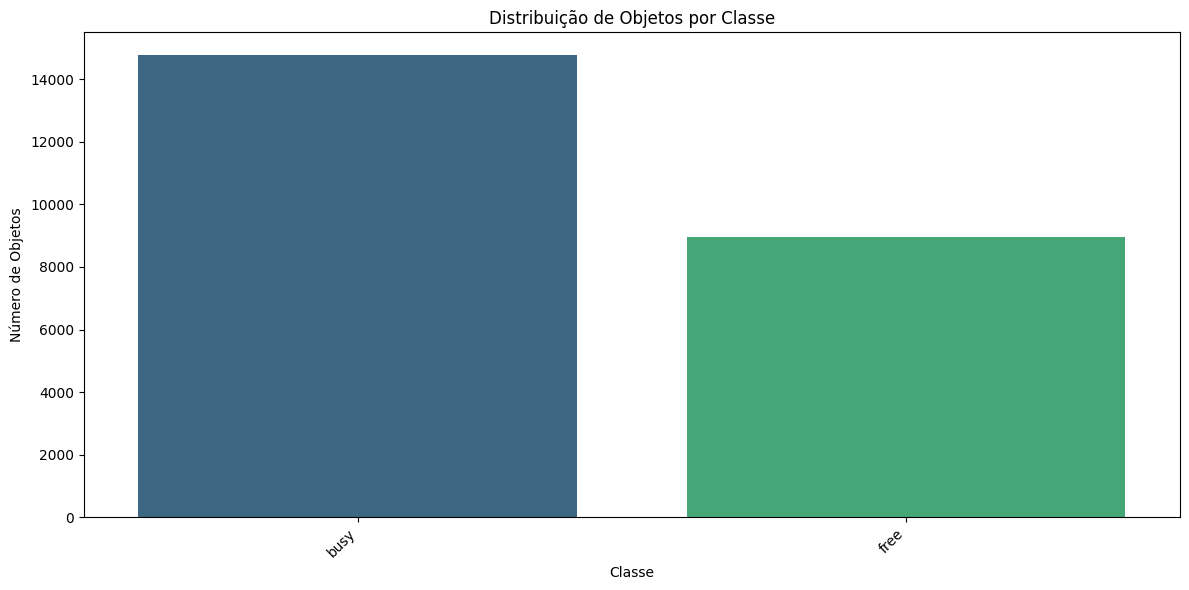

In [7]:
import yaml
import os
import cv2
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pandas as pd # Adicionado importação de pandas

# Carregar o arquivo data.yaml
with open(data_yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Caminho base do dataset
dataset_base_path = os.path.dirname(data_yaml_path)

# Mapeamento de IDs para nomes de classes
class_names = data['names']
num_classes = len(class_names)

# Dicionários para armazenar informações
class_counts = defaultdict(int)
image_resolutions = {'width': [], 'height': []}

print(f"Classes encontradas: {class_names}")

# Função para carregar anotações YOLO e contar classes
def load_yolo_annotations(annotation_path, image_size=None):
    try:
        with open(annotation_path, 'r') as f:
            lines = f.readlines()
        counts = defaultdict(int)
        for line in lines:
            parts = line.strip().split()
            class_id = int(parts[0])
            counts[class_id] += 1
        return counts
    except FileNotFoundError:
        return {}

# Processar conjuntos de treino, validação e teste
for subset in ['train', 'valid', 'test']:
    print(f"\nProcessando subset: {subset}")
    image_dir = os.path.join(dataset_base_path, subset, 'images')
    label_dir = os.path.join(dataset_base_path, subset, 'labels')

    if not os.path.exists(image_dir):
        print(f"Diretório de imagens não encontrado para {subset}: {image_dir}")
        continue
    if not os.path.exists(label_dir):
        print(f"Diretório de labels não encontrado para {subset}: {label_dir}")
        continue

    image_paths = glob(os.path.join(image_dir, '*'))
    print(f"Encontradas {len(image_paths)} imagens em {subset}")

    for img_path in image_paths:
        # Obter resolução da imagem
        img = cv2.imread(img_path)
        if img is not None:
            h, w, _ = img.shape
            image_resolutions['width'].append(w)
            image_resolutions['height'].append(h)

        # Obter anotações
        # Corrigir a extração do nome base do arquivo para corresponder aos arquivos de anotação
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        annotation_path = os.path.join(label_dir, base_name + '.txt')

        annotations = load_yolo_annotations(annotation_path)
        for class_id, count in annotations.items():
            class_counts[class_id] += count


# 1. Análise da Quantidade por Classe (e Desbalanceamento)
print("\n--- Quantidade de Objetos por Classe ---")
total_objects = sum(class_counts.values())
class_data = []
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    percentage = (count / total_objects) * 100 if total_objects > 0 else 0
    class_data.append({'Class': class_names[class_id], 'Count': count, 'Percentage': percentage})
    print(f"Classe {class_names[class_id]} ({class_id}): {count} objetos ({percentage:.2f}%) ")

df_class_counts = pd.DataFrame(class_data)

plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', data=df_class_counts, palette='viridis')
plt.title('Distribuição de Objetos por Classe')
plt.xlabel('Classe')
plt.ylabel('Número de Objetos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Análise de Resoluções de Imagem ---
       Width  Height
count  727.0   727.0
mean   640.0   640.0
std      0.0     0.0
min    640.0   640.0
25%    640.0   640.0
50%    640.0   640.0
75%    640.0   640.0
max    640.0   640.0


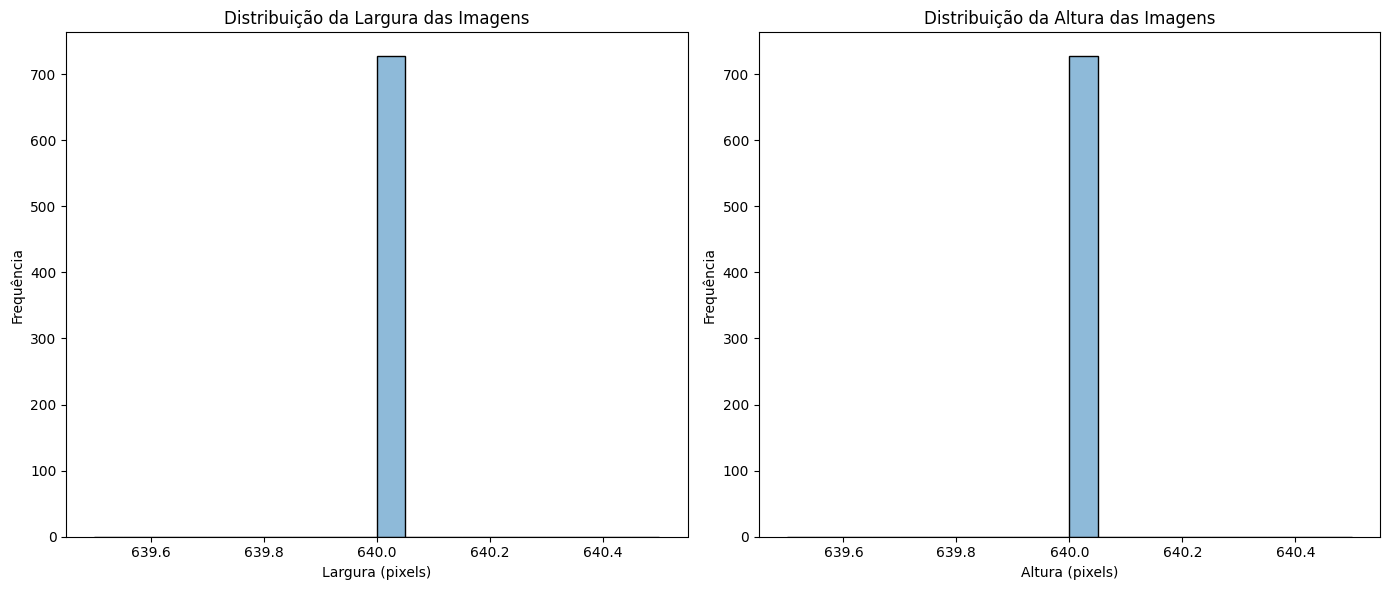

In [8]:
import pandas as pd

# 2. Análise de Resoluções de Imagem
print("\n--- Análise de Resoluções de Imagem ---")
if image_resolutions['width'] and image_resolutions['height']:
    df_resolutions = pd.DataFrame({
        'Width': image_resolutions['width'],
        'Height': image_resolutions['height']
    })

    print(df_resolutions.describe())

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(df_resolutions['Width'], bins=20, kde=True)
    plt.title('Distribuição da Largura das Imagens')
    plt.xlabel('Largura (pixels)')
    plt.ylabel('Frequência')

    plt.subplot(1, 2, 2)
    sns.histplot(df_resolutions['Height'], bins=20, kde=True)
    plt.title('Distribuição da Altura das Imagens')
    plt.xlabel('Altura (pixels)')
    plt.ylabel('Frequência')

    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma resolução de imagem encontrada.")

## Análise de Condições de Luz

Vamos analisar as condições de luz das imagens para entender a variabilidade no dataset. Isso pode ser importante para o treinamento do modelo, pois a performance pode ser afetada por diferentes iluminações.


--- Análise de Condições de Luz ---
       Brightness
count  727.000000
mean    85.247964
std     31.762909
min     12.235103
25%     60.420776
50%     83.079641
75%    109.455779
max    171.484673


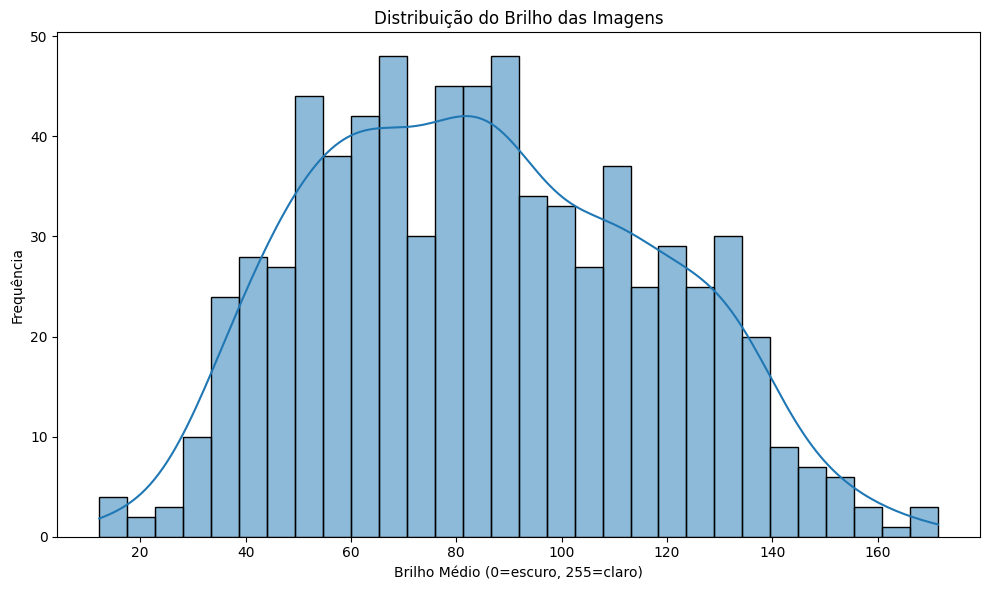



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



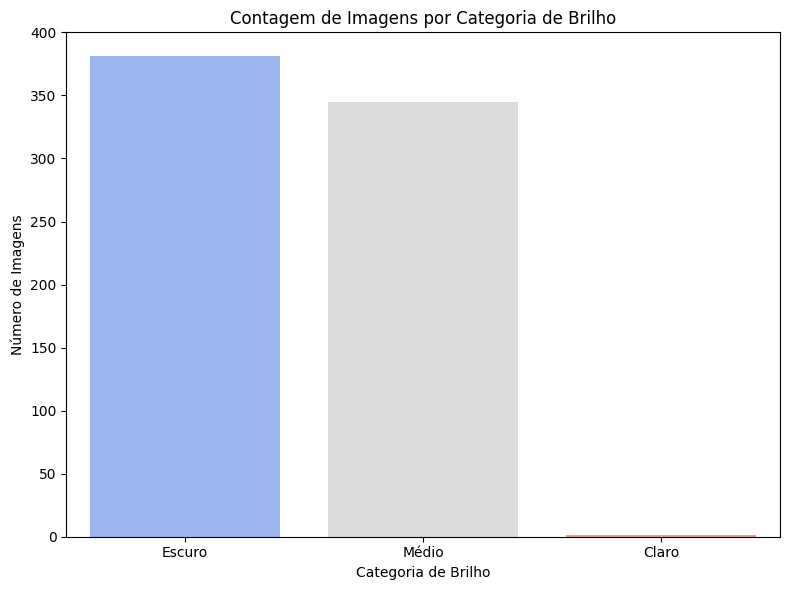

In [9]:
import numpy as np

# Função para estimar o brilho de uma imagem
def estimate_brightness(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    # Converte a imagem para escala de cinza e calcula a média dos pixels
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)
    return brightness

# Listar todas as imagens
all_image_paths = []
for subset in ['train', 'valid', 'test']:
    image_dir = os.path.join(dataset_base_path, subset, 'images')
    if os.path.exists(image_dir):
        all_image_paths.extend(glob(os.path.join(image_dir, '*')))

brightness_values = []
for img_path in all_image_paths:
    brightness = estimate_brightness(img_path)
    if brightness is not None:
        brightness_values.append(brightness)

# 3. Análise de Condições de Luz
print("\n--- Análise de Condições de Luz ---")
if brightness_values:
    df_brightness = pd.DataFrame({'Brightness': brightness_values})
    print(df_brightness.describe())

    plt.figure(figsize=(10, 6))
    sns.histplot(df_brightness['Brightness'], bins=30, kde=True)
    plt.title('Distribuição do Brilho das Imagens')
    plt.xlabel('Brilho Médio (0=escuro, 255=claro)')
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()

    # Categorizar o brilho para melhor visualização
    bins = [0, 85, 170, 255]
    labels = ['Escuro', 'Médio', 'Claro']
    df_brightness['Category'] = pd.cut(df_brightness['Brightness'], bins=bins, labels=labels, include_lowest=True)

    plt.figure(figsize=(8, 6))
    sns.countplot(x='Category', data=df_brightness, palette='coolwarm', order=labels)
    plt.title('Contagem de Imagens por Categoria de Brilho')
    plt.xlabel('Categoria de Brilho')
    plt.ylabel('Número de Imagens')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor de brilho encontrado.")

A análise da distribuição de brilho das imagens fornece insights sobre as condições de iluminação presentes no dataset. Se o dataset for predominantemente 'escuro' ou 'claro', isso pode indicar um viés que pode afetar o desempenho do modelo em condições de luz diferentes. Um dataset com uma boa distribuição de brilho é geralmente mais robusto.

Neste caso, podemos observar a distribuição de brilho no histograma e a contagem por categoria para entender a proporção de imagens em cada condição de luz.

# **3. Treinando o modelo**

A classe YOLO da ultralytics permite que treinamos facilmente. Podemos especificar o tipo de modelo (por exemplo, yolov8n.pt para detecção, yolov8n-cls.pt para classificação), o arquivo data.yaml que descreve o conjunto de dados e parâmetros de treinamento como o número de épocas, tamanho da imagem e tamanho do lote.

In [10]:
from ultralytics import YOLO

# Carrega um modelo pré-treinado para detecção de objetos (yolov8n.pt)
model_detec = YOLO('yolov8n.pt')  # Ou 'yolov8n-cls.pt' para classificação, 'yolov8n-seg.pt' para segmentação

# Treina o modelo usando o arquivo data.yaml do Roboflow
results_detec = model_detec.train(
    data=data_yaml_path, # Caminho para o arquivo data.yaml
    epochs=50,            # Número de épocas de treinamento (50)
    imgsz=640,            # Tamanho da imagem de entrada
    batch=16,             # Tamanho do lote
    name='custom_yolov8_detec', # Nome para salvar os resultados do treinamento
    save=True
)

print("Treinamento concluído com o modelo de detecção! Os resultados foram salvos em runs/detect/custom_yolov8_detec (ou similar).")

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Parking-places-3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolov8_detec-2, nbs=64, nms=None, 

# **4. Validação**

Executando validação no conjunto de validação...
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1698.7±350.7 MB/s, size: 69.5 KB)
val: Scanning /content/Parking-places-3/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 13.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3s/it 5.2s
                   all         58       1797      0.885      0.688      0.668       0.37
                  busy         58       1090      0.915      0.841      0.828      0.536
                  free         55        707      0.855      0.535      0.508      0.204
Speed: 17.3ms preprocess, 25.0ms inference, 0.0ms loss, 8.5ms postprocess per image
Results saved to /content/runs/detect/val-3

Métricas de Validação:
mAP50: 0.668
mAP50-95

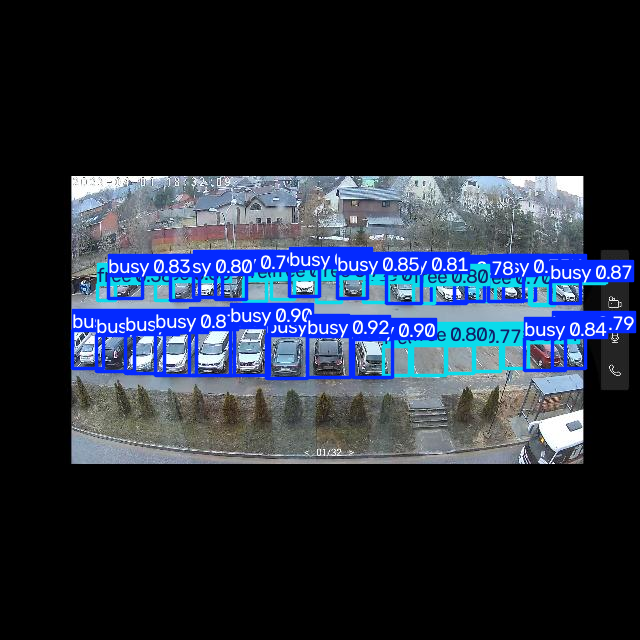

Inferindo em: /content/Parking-places-3/valid/images/GOPR6592_JPG.rf.4863a85bff3871f892d86cecd475ad57.jpg

image 1/1 /content/Parking-places-3/valid/images/GOPR6592_JPG.rf.4863a85bff3871f892d86cecd475ad57.jpg: 640x640 28 busys, 7 frees, 12.2ms
Speed: 1.1ms preprocess, 12.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


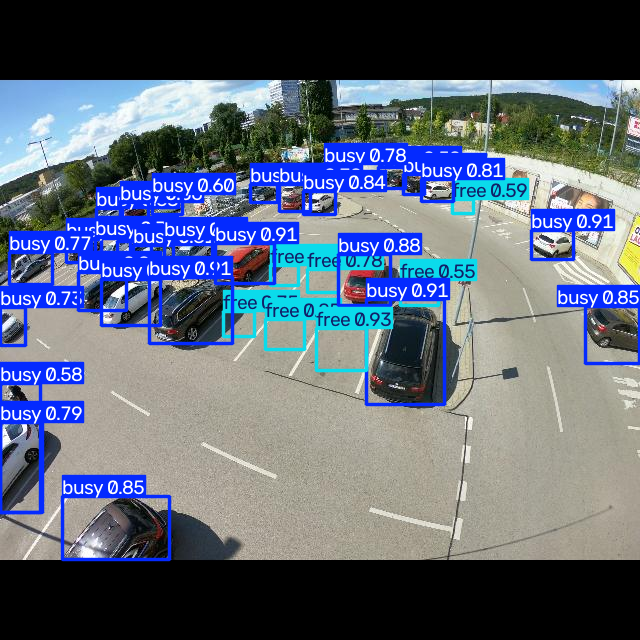

In [11]:
from ultralytics import YOLO
import random
import os
from glob import glob
from PIL import Image
from IPython.display import display

# Carrega o modelo com os pesos treinados
best_model = YOLO('/content/runs/detect/custom_yolov8_detec/weights/best.pt')

# 1. Obter métricas de validação no conjunto de validação
# O caminho para o arquivo data.yaml já está disponível como `data_yaml_path`
dataset_base_path = os.path.dirname(data_yaml_path) # Define dataset_base_path
# Executar a validação. Os resultados e as curvas serão salvos no diretório de runs.
print("Executando validação no conjunto de validação...")
metrics = best_model.val(data=data_yaml_path, imgsz=640, conf=0.5)

print("\nMétricas de Validação:")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']:.3f}")
print(f"mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']:.3f}")


# 2. Ajustar para obter 2 imagens do dataset de validação (Coloquei 2 imagens só para visualizar algumas)
# Caminho para as imagens de validação
val_image_dir = os.path.join(dataset_base_path, 'valid', 'images')
val_image_paths = glob(os.path.join(val_image_dir, '*'))

if len(val_image_paths) >= 2:
    selected_images = random.sample(val_image_paths, 2)
elif len(val_image_paths) > 0:
    # Fallback if there are less than 2 validation images but at least one
    selected_images = val_image_paths
    print(f"Apenas {len(selected_images)} imagens de validação disponíveis. Usando todas elas.")
else:
    selected_images = []
    print("Nenhuma imagem de validação encontrada.")

if selected_images:
    print("\nRealizando inferência em imagens aleatórias do conjunto de validação:")
    # Executa inferência nas imagens selecionadas
    for img_path in selected_images:
        print(f"Inferindo em: {img_path}")
        # predict returns a list of Results objects
        results = best_model.predict(img_path, conf=0.5, save=False, show=False)
        # Exibe o resultado com as bounding boxes detectadas
        for r in results:
            im_bgr = r.plot()  # plot a BGR numpy array of predictions
            im_rgb = Image.fromarray(im_bgr[..., ::-1]) # Convert BGR to RGB
            display(im_rgb) # Display using IPython.display

Comparação Visual: Detecção (Caixas) × Segmentação (Máscaras)

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Imagem de teste fixa por enquanto
image_path = '/content/Parking-places-3/valid/images/325b89f3-0369-4204-b8b2-77bf4388b8a5_jpeg.rf.2878337ab73446b9eee67106d97ab4cd.jpg'

# 1. Detector: usa os SEUS pesos treinados
res_det = YOLO('runs/detect/custom_yolov8_detec/weights/best.pt').predict(image_path, conf=0.4)[0]

# 2. Segmentador: aqui a gente NAO treinou nada, usa o yolov8n-seg pronto do COCO direto
#    (nao carrega de 'runs/' porque nunca rodamos um treino de segmentacao no dataset
#    das vagas -- o dataset original nao tem mascara, so bounding box de busy/free).
#    Entao essa mascara e de veiculo generico (carro/onibus/caminhao), nao de vaga
#    ocupada/livre. E a decisao que a gente tomou pra Fase 3, documentada na celula
#    de markdown acima.
res_seg = YOLO('yolov8n-seg.pt').predict(image_path, conf=0.4)[0]

# Renderização
img_det = res_det.plot(masks=False)              # Apenas Bounding Boxes
img_seg = res_seg.plot(boxes=True, masks=True)    # Caixas + Máscaras de polígonos

# Exibição Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB))
axes[0].set_title("Detecção (Bounding Box Fine-Tunado)")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_seg, cv2.COLOR_BGR2RGB))
axes[1].set_title("Segmentação (Máscaras Pré-treinadas)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Avaliação

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1678.2±355.0 MB/s, size: 54.3 KB)
val: Scanning /content/Parking-places-3/test/labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 9.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.6s
                   all         39       1175      0.859       0.76      0.818      0.439
                  busy         39        740      0.904      0.918      0.961      0.626
                  free         39        435      0.814      0.603      0.675      0.253
Speed: 5.1ms preprocess, 6.6ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/detect/avaliacao_teste_detec-2

RELATÓRIO DE AVALIAÇÃO - BASE DE TESTE
Precisão Média (Precision):  0.8591
Revo

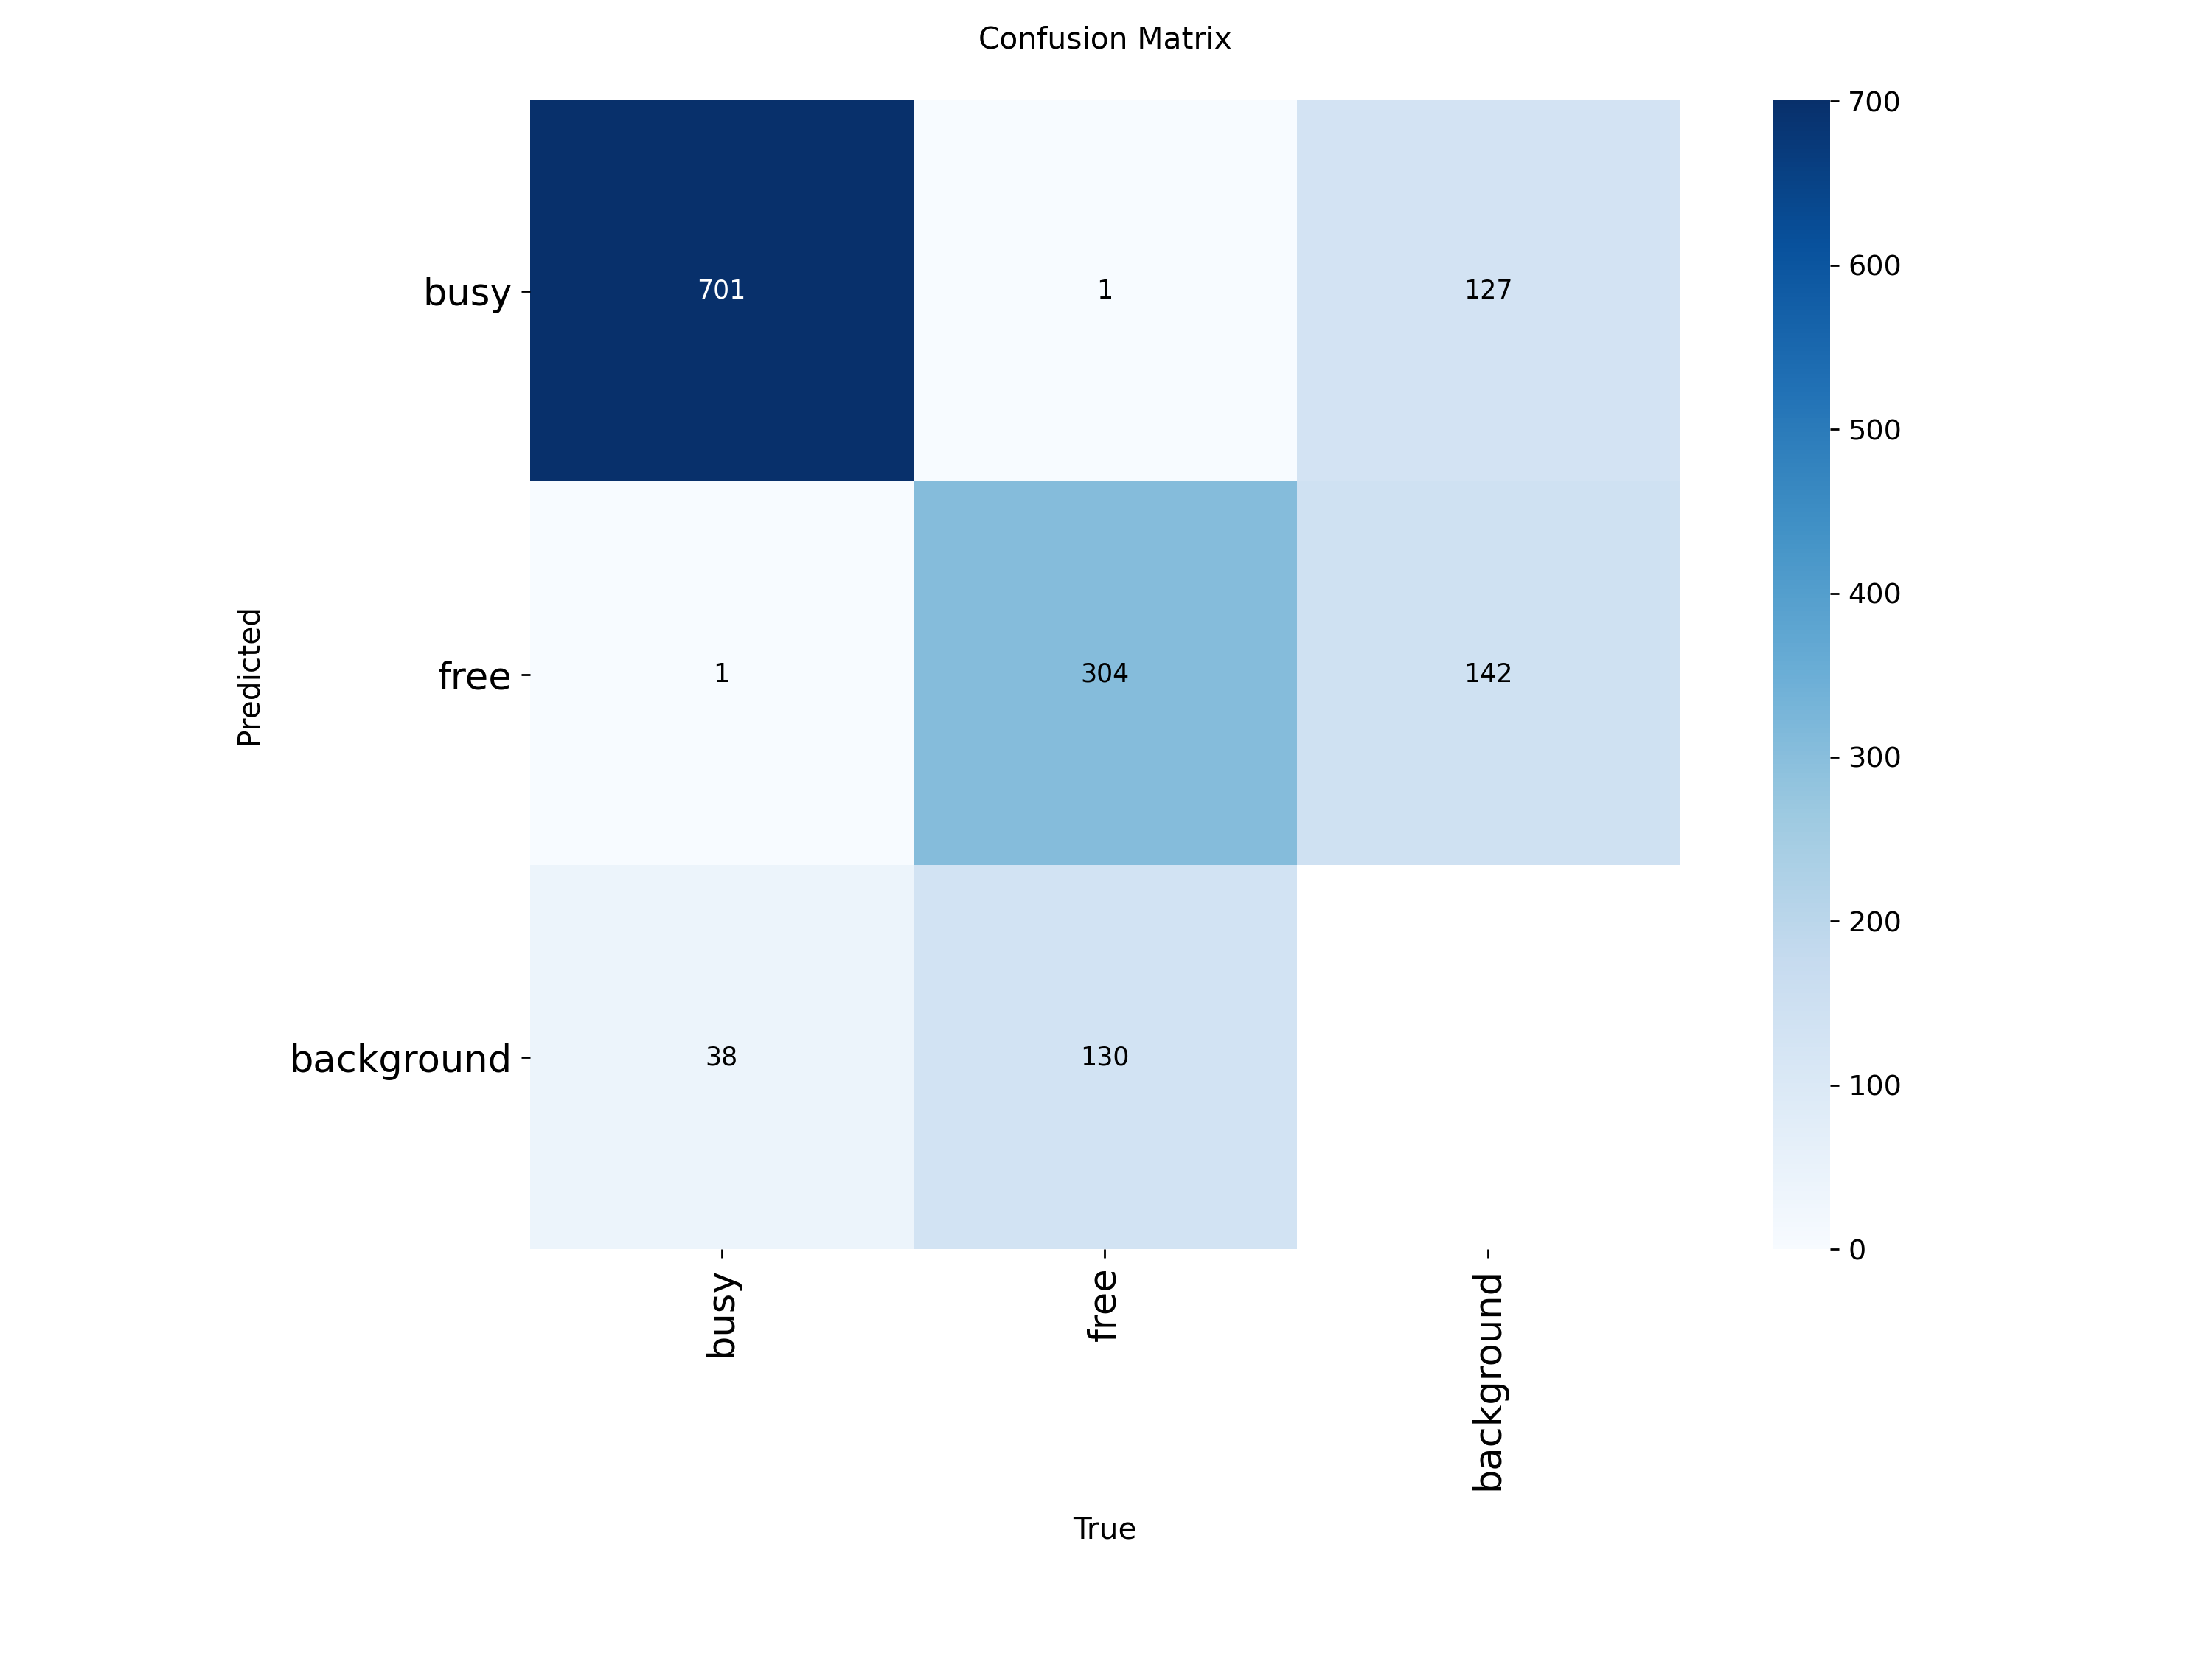


--- Exibindo: confusion_matrix_normalized.png ---


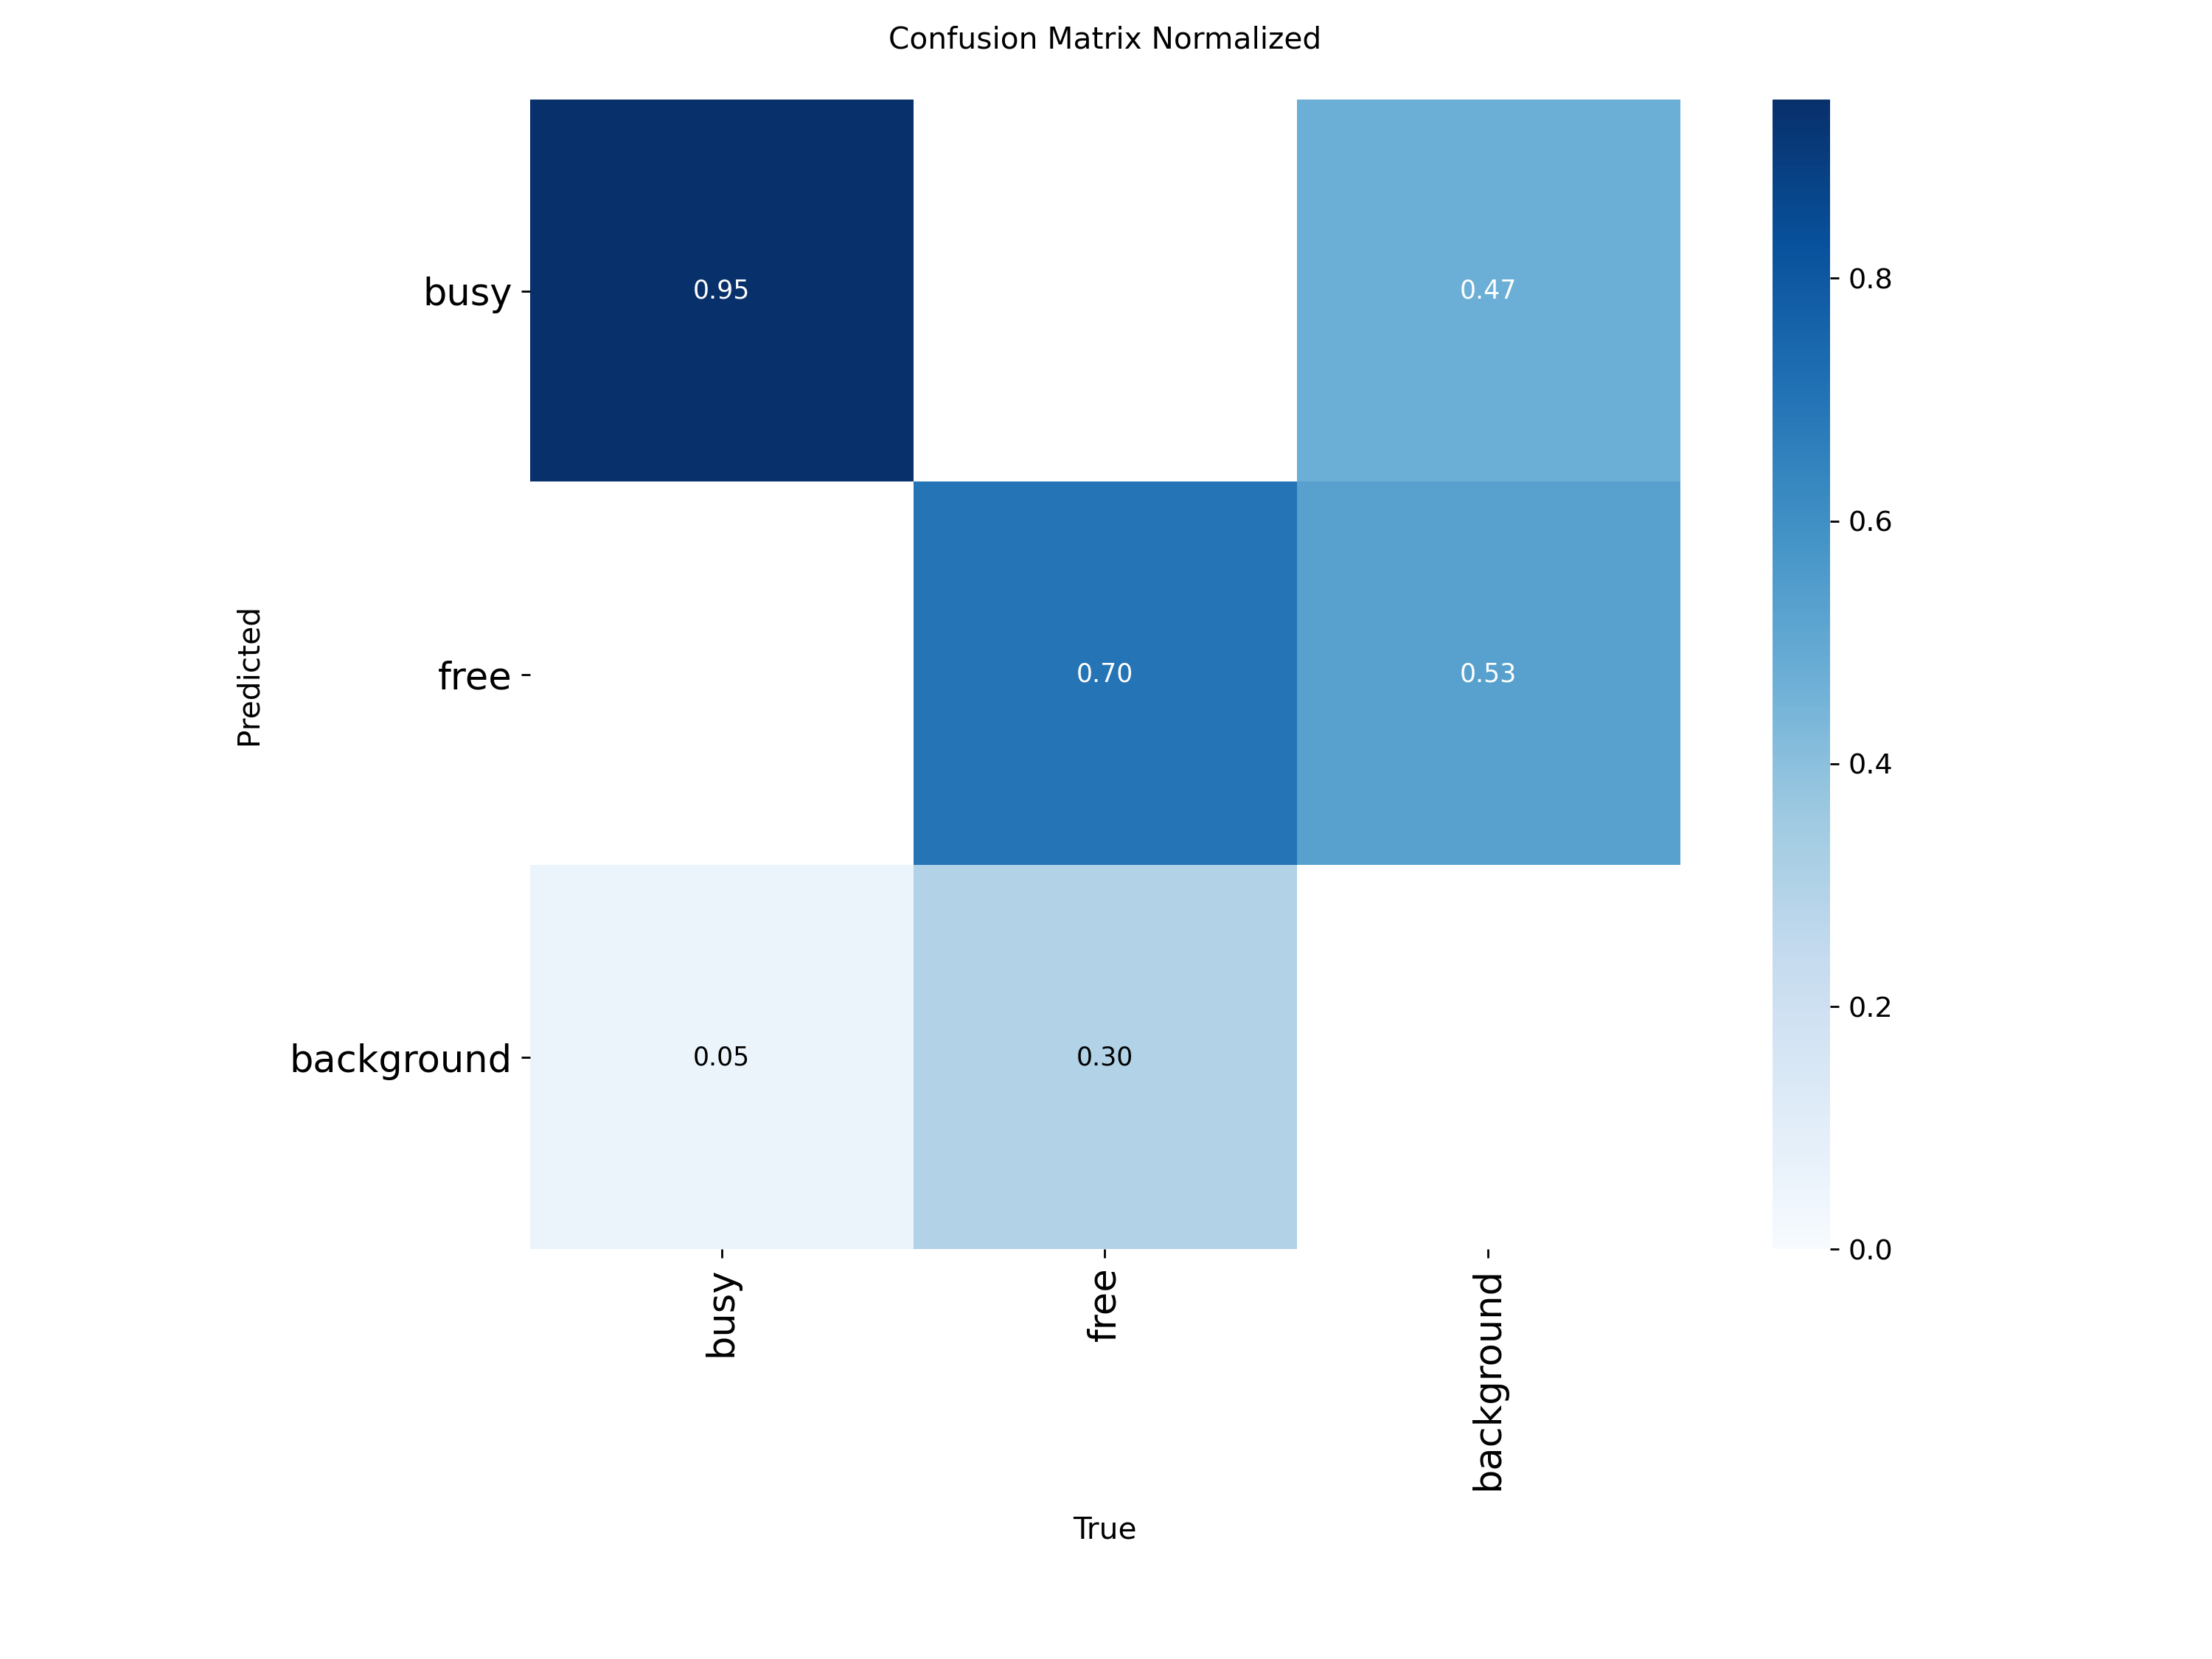


--- Exibindo: BoxPR_curve.png ---


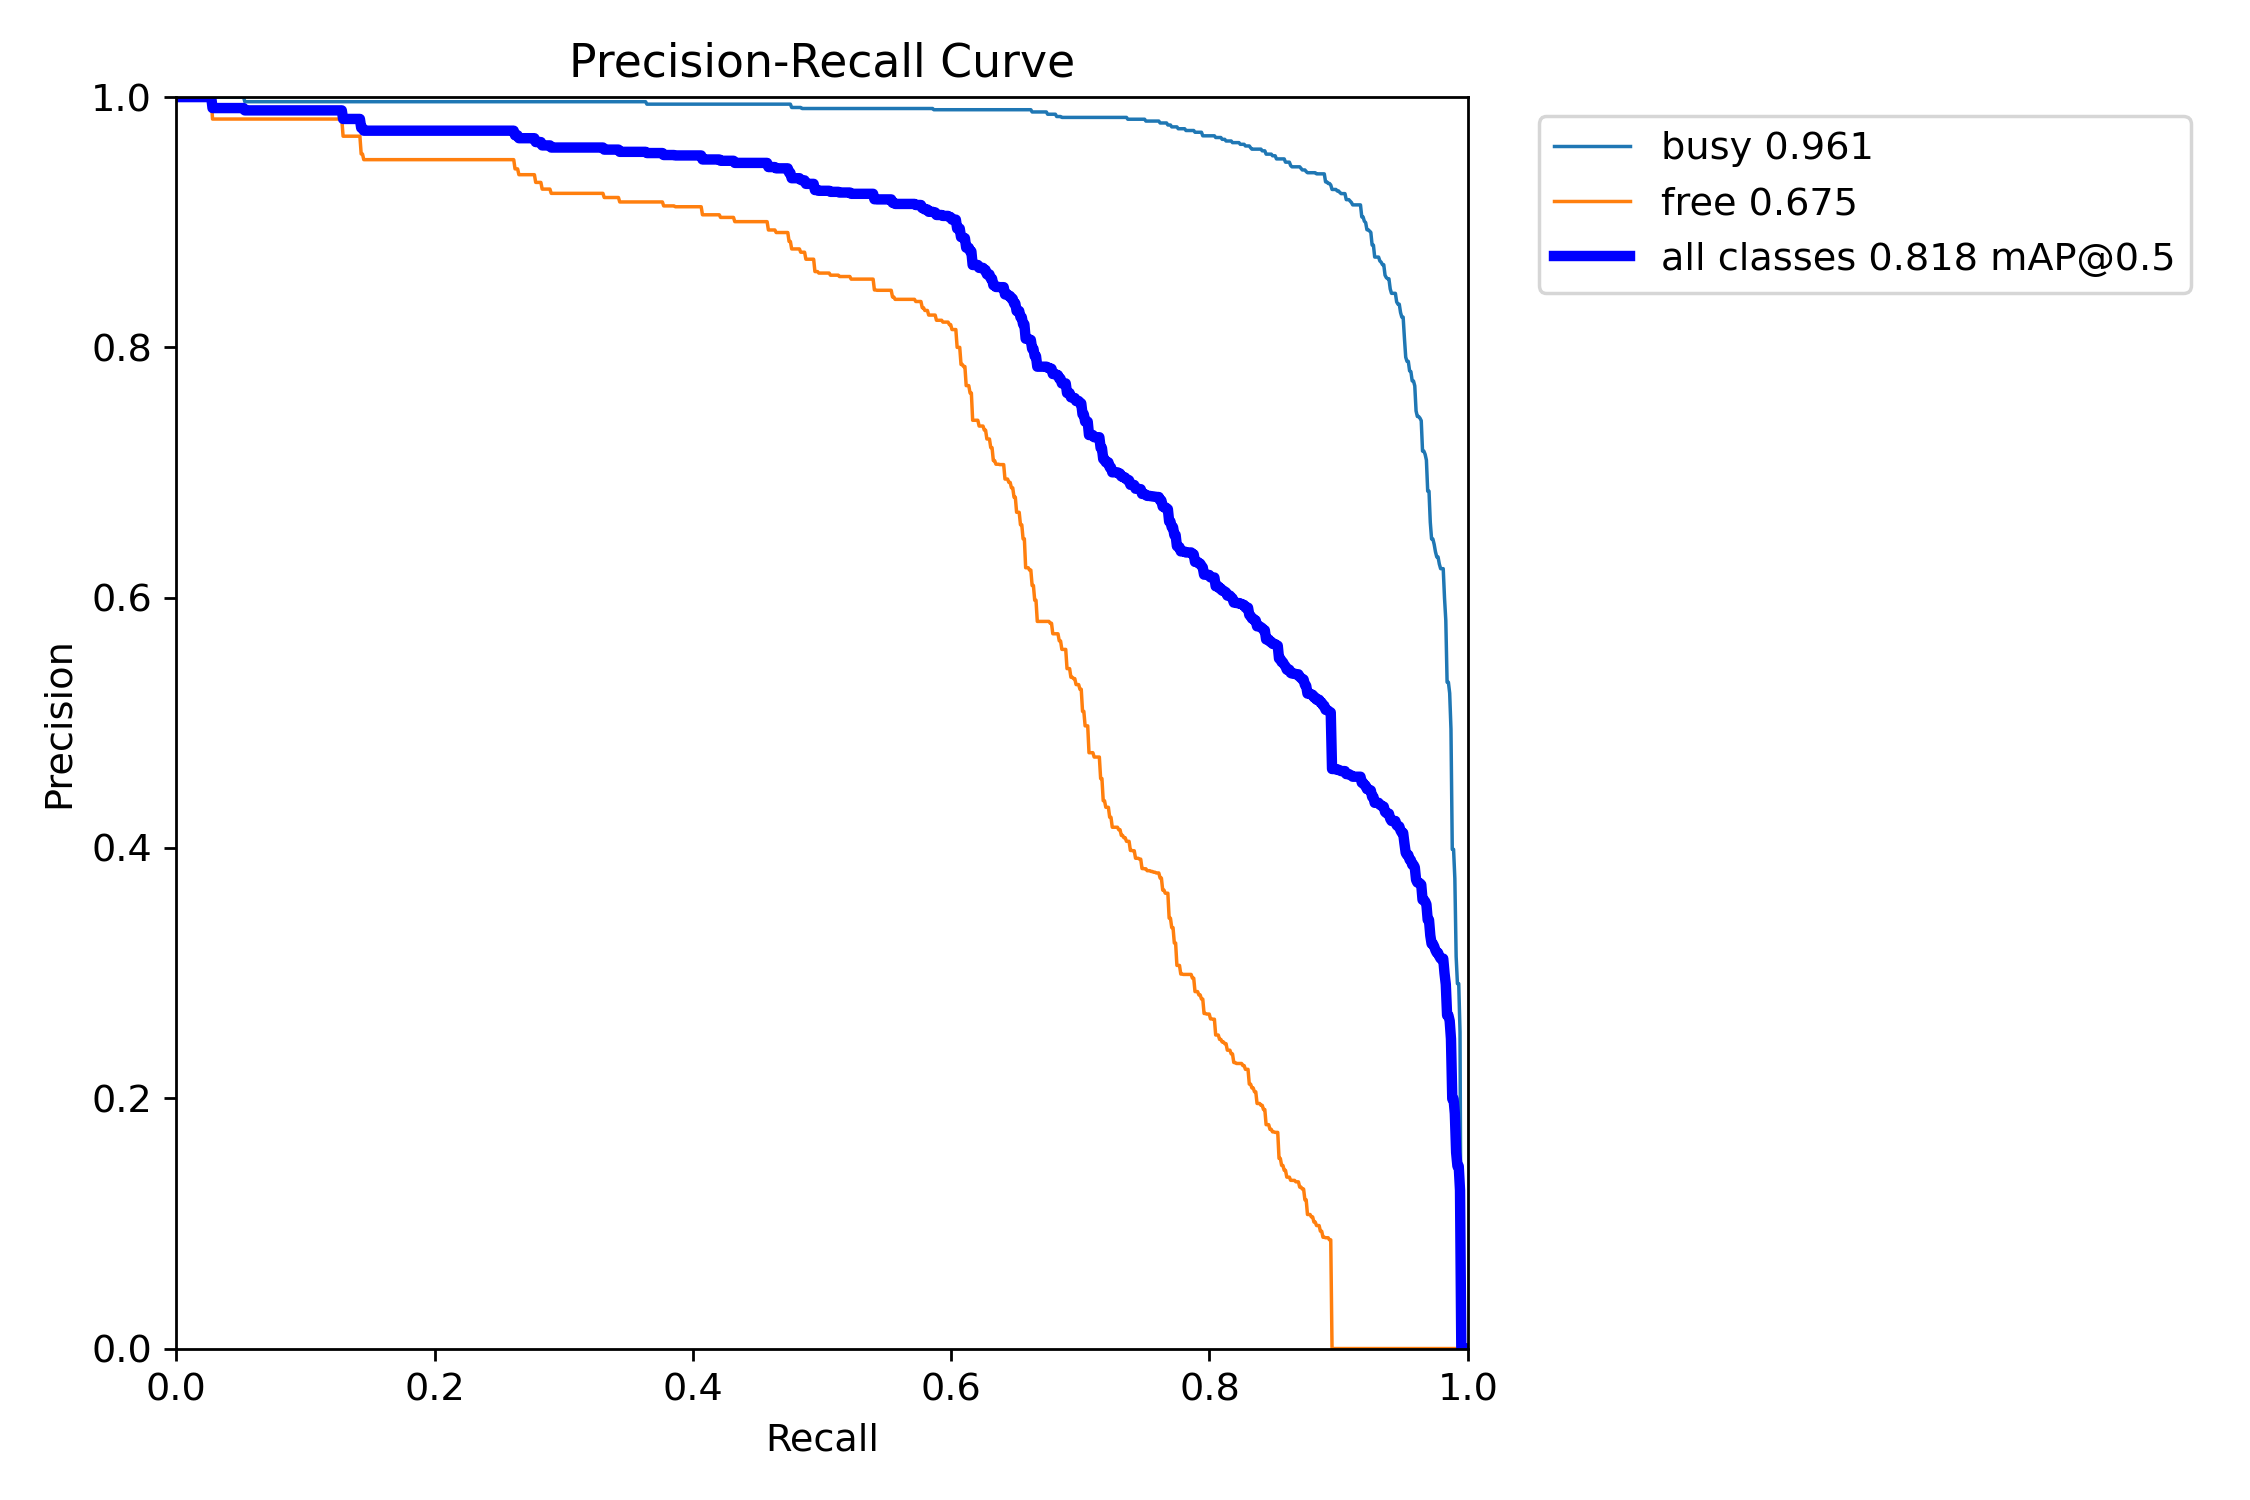


--- Exibindo: BoxR_curve.png ---


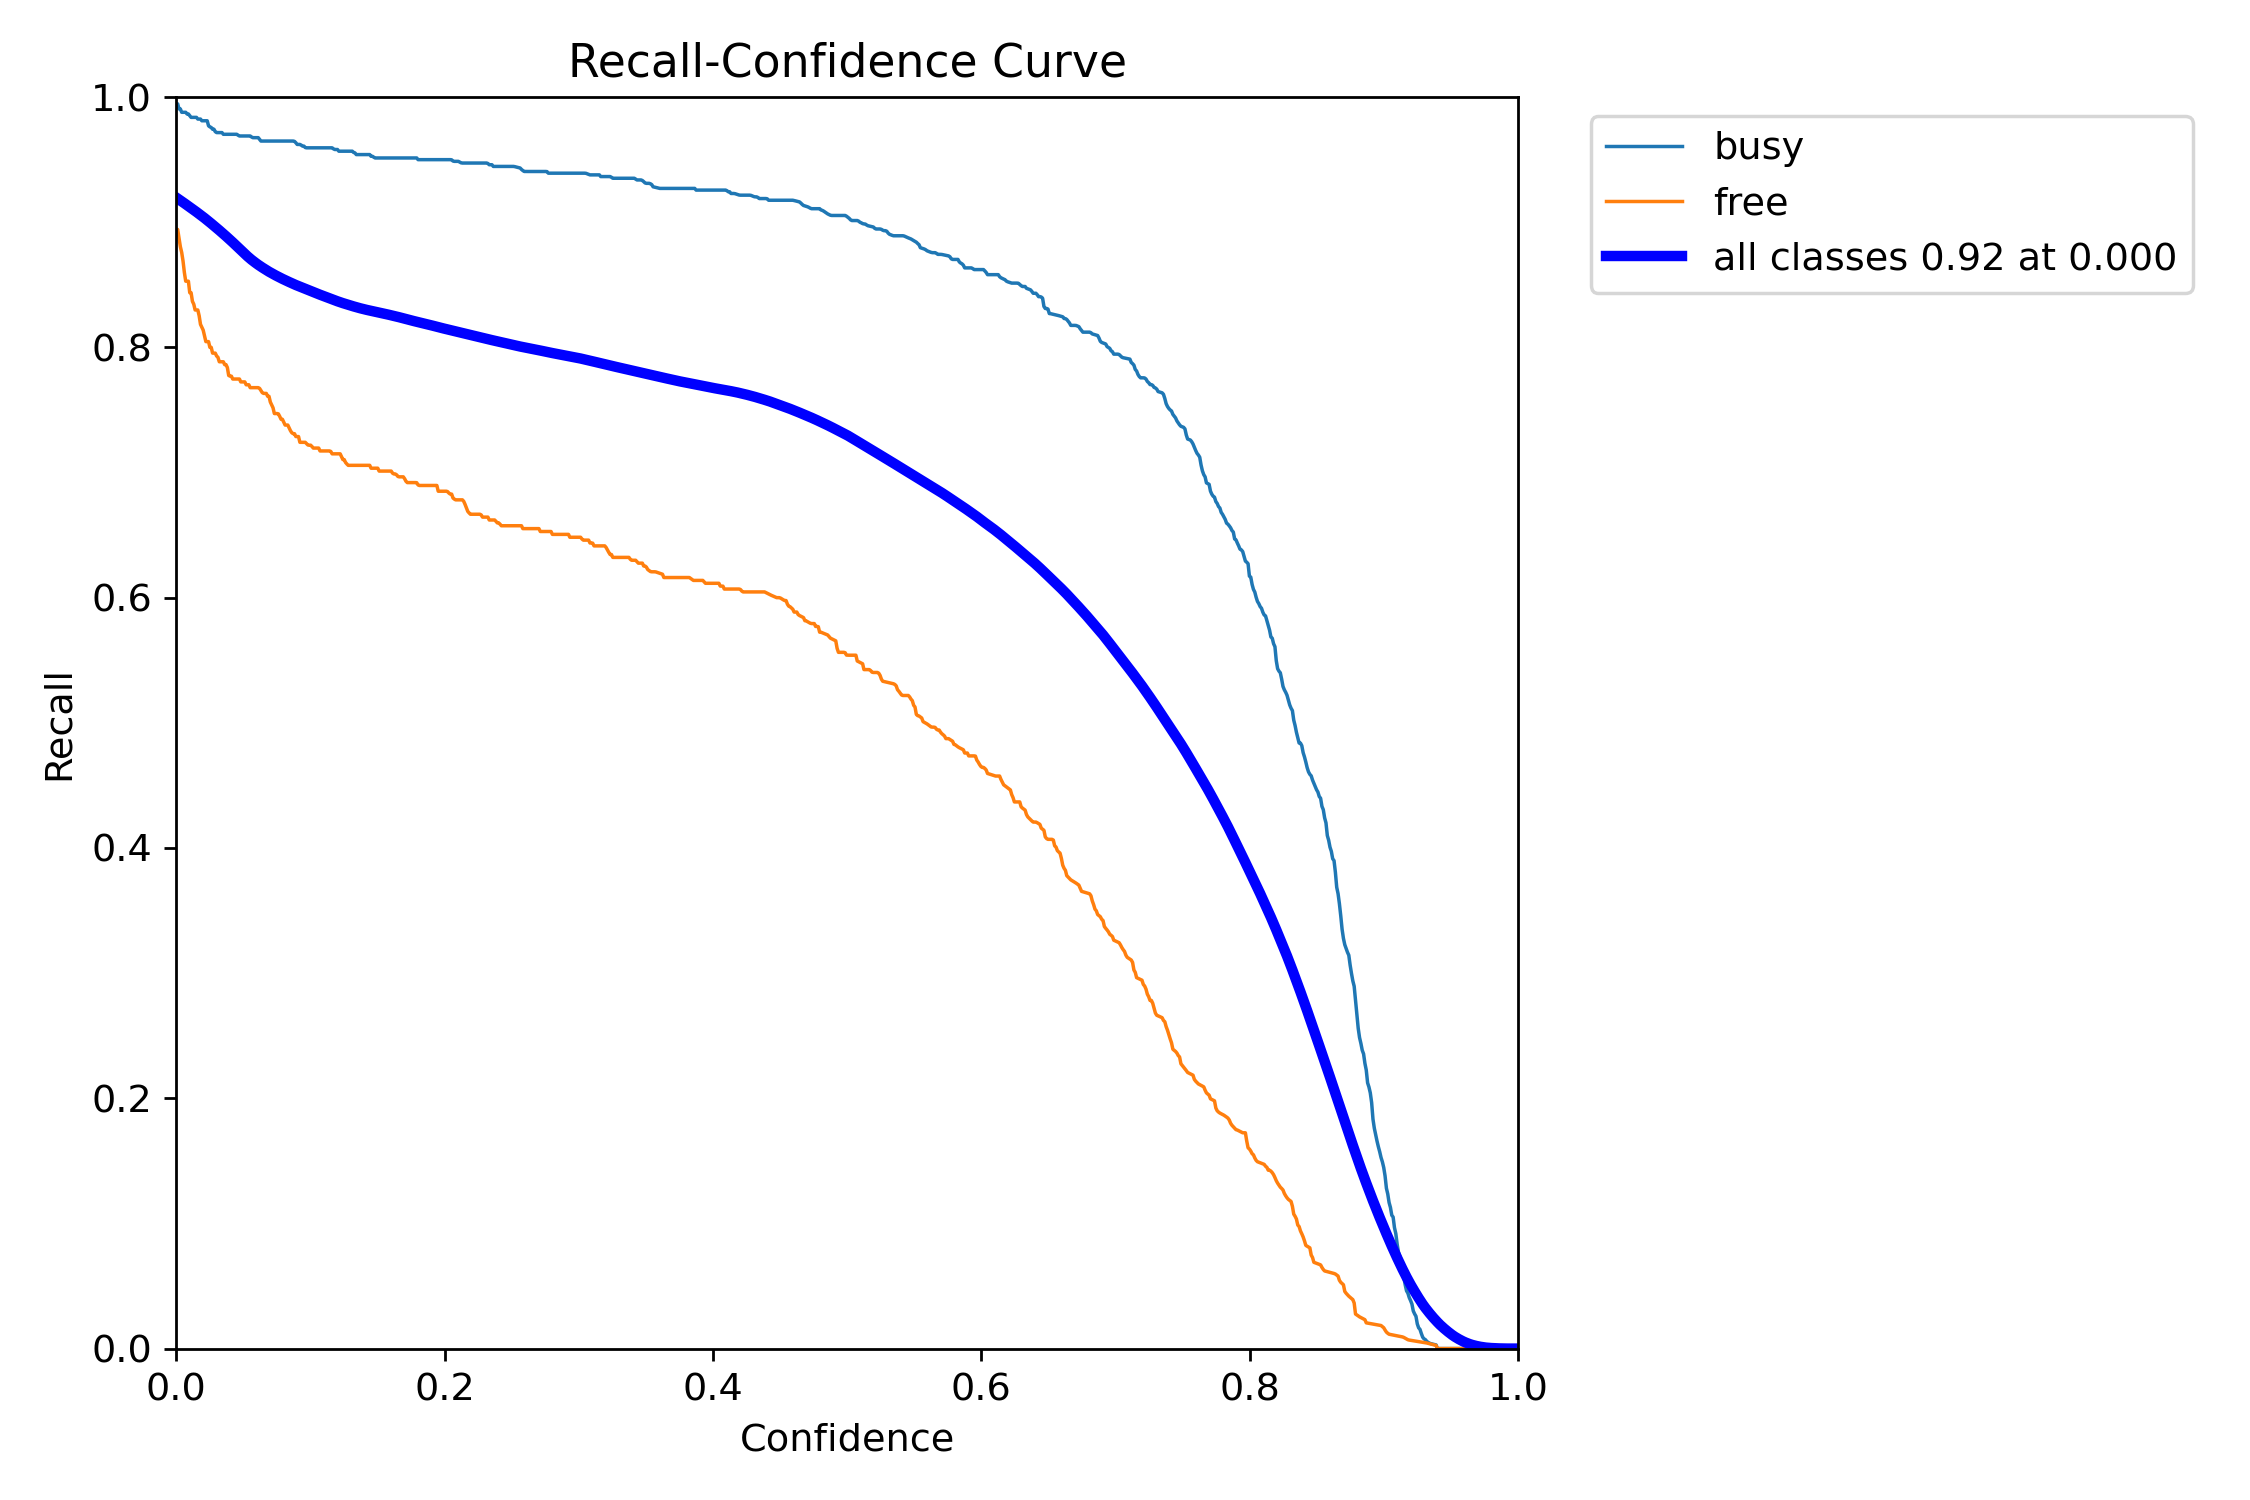


--- Exibindo: BoxP_curve.png ---


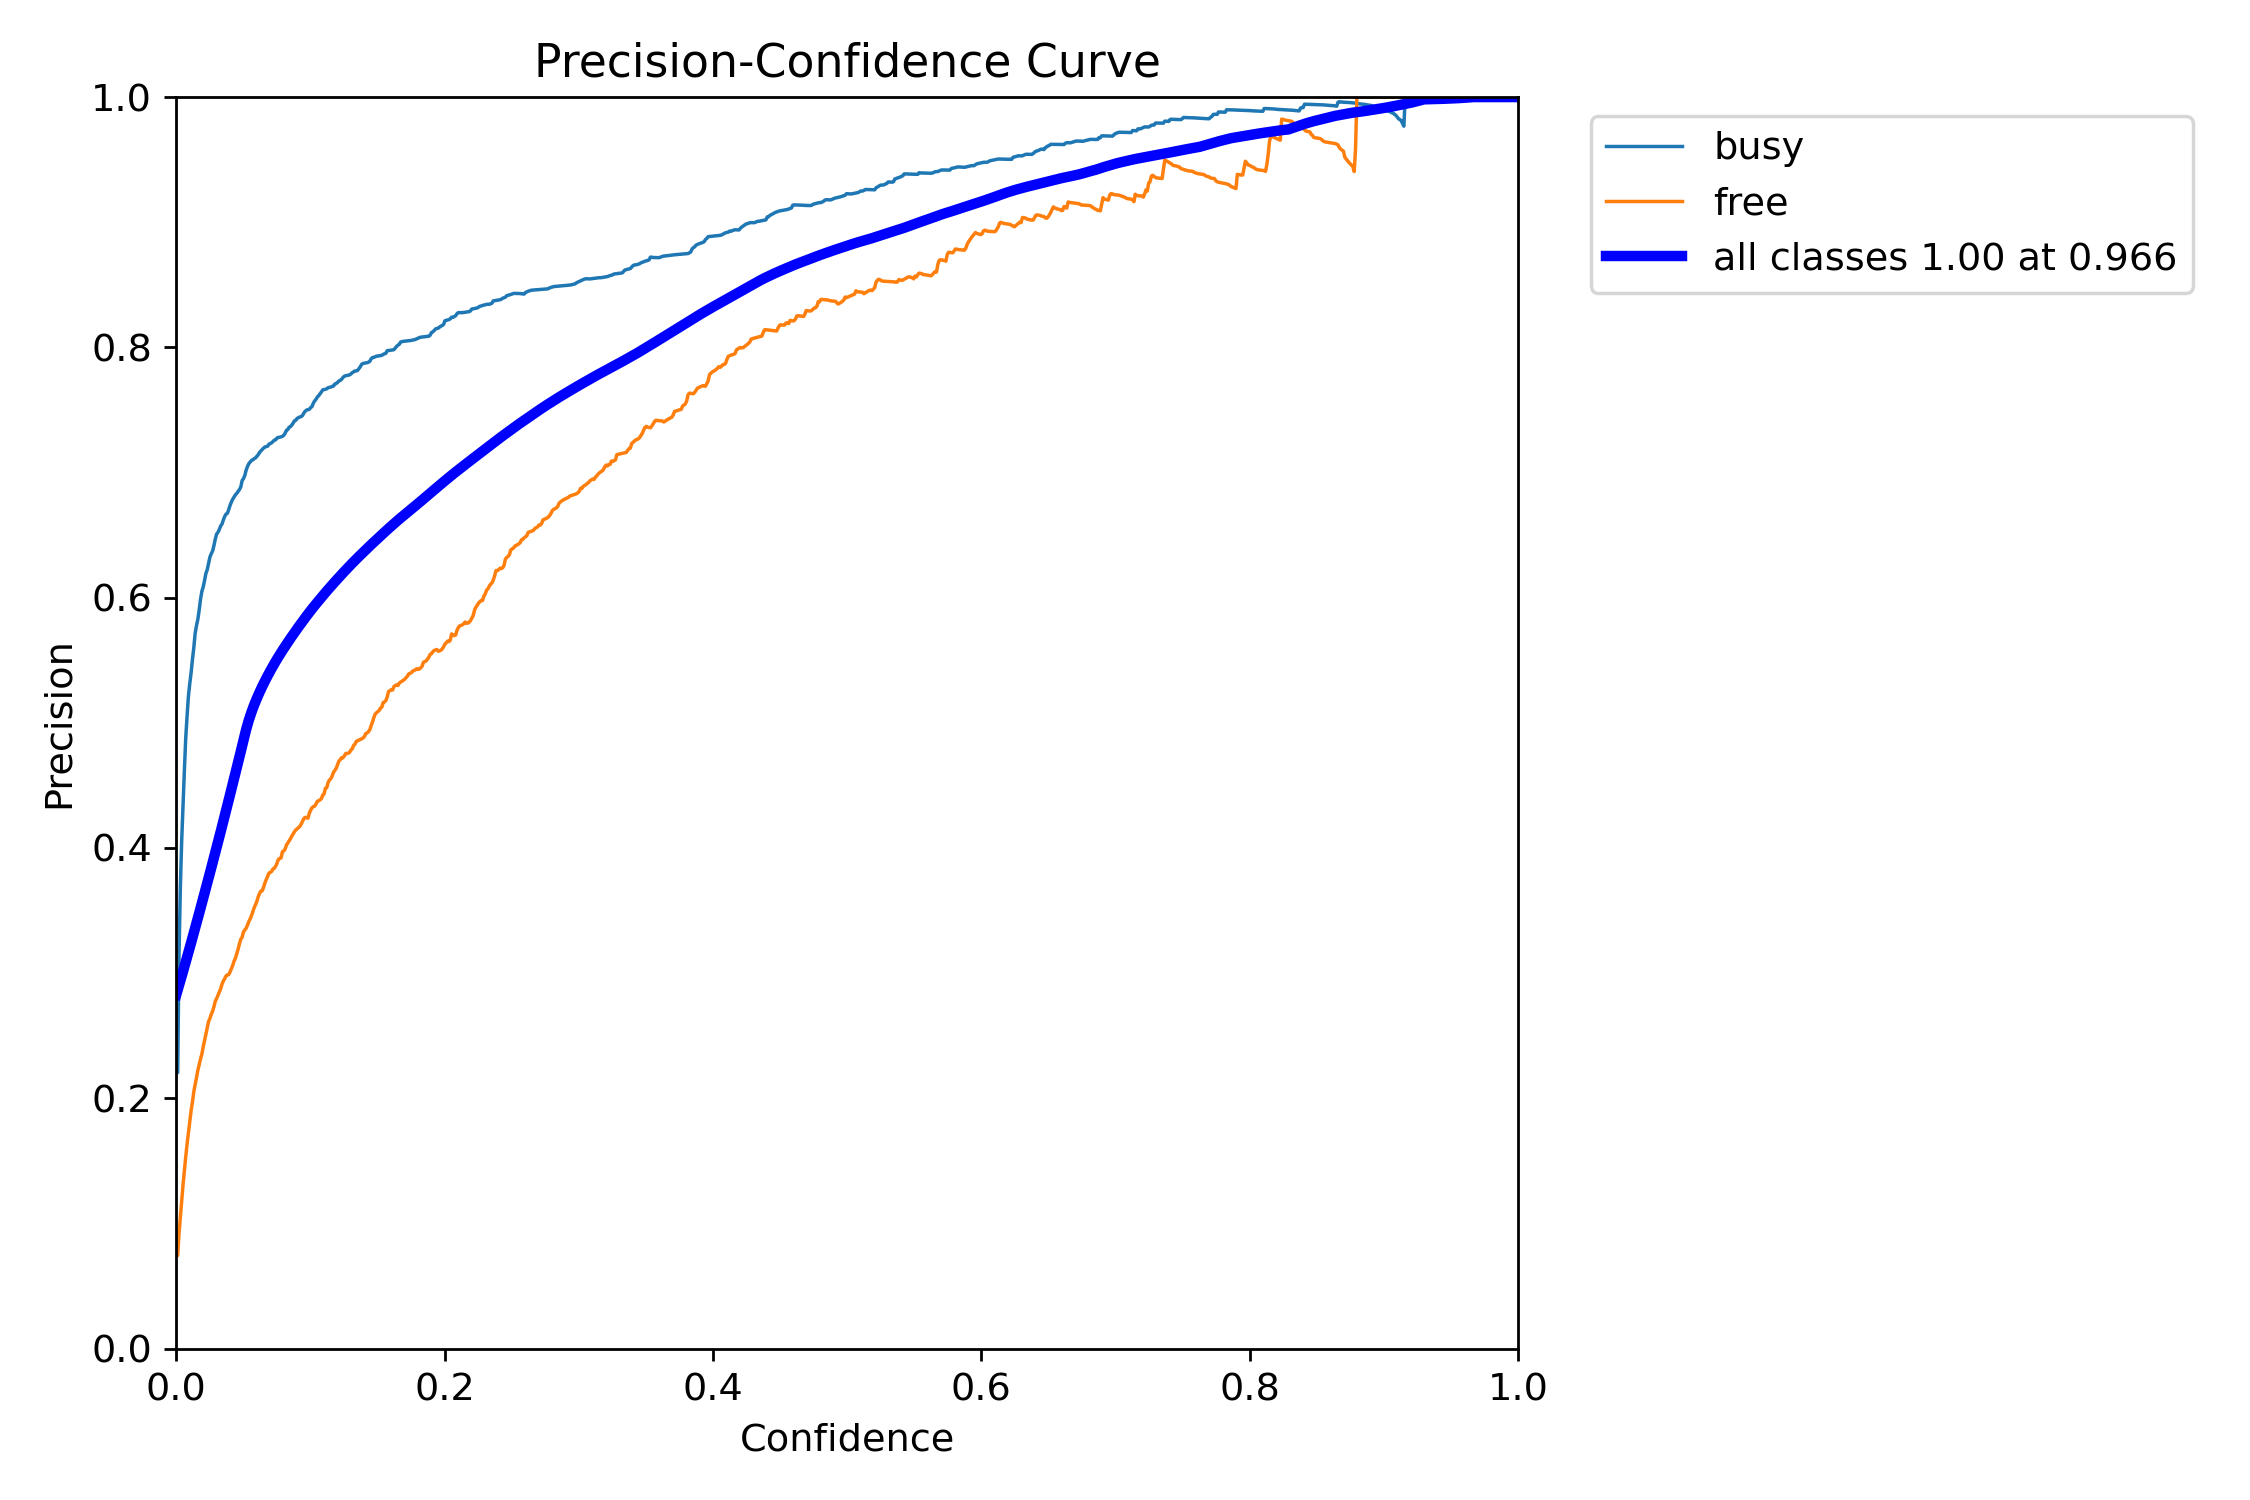


--- Exibindo: BoxF1_curve.png ---


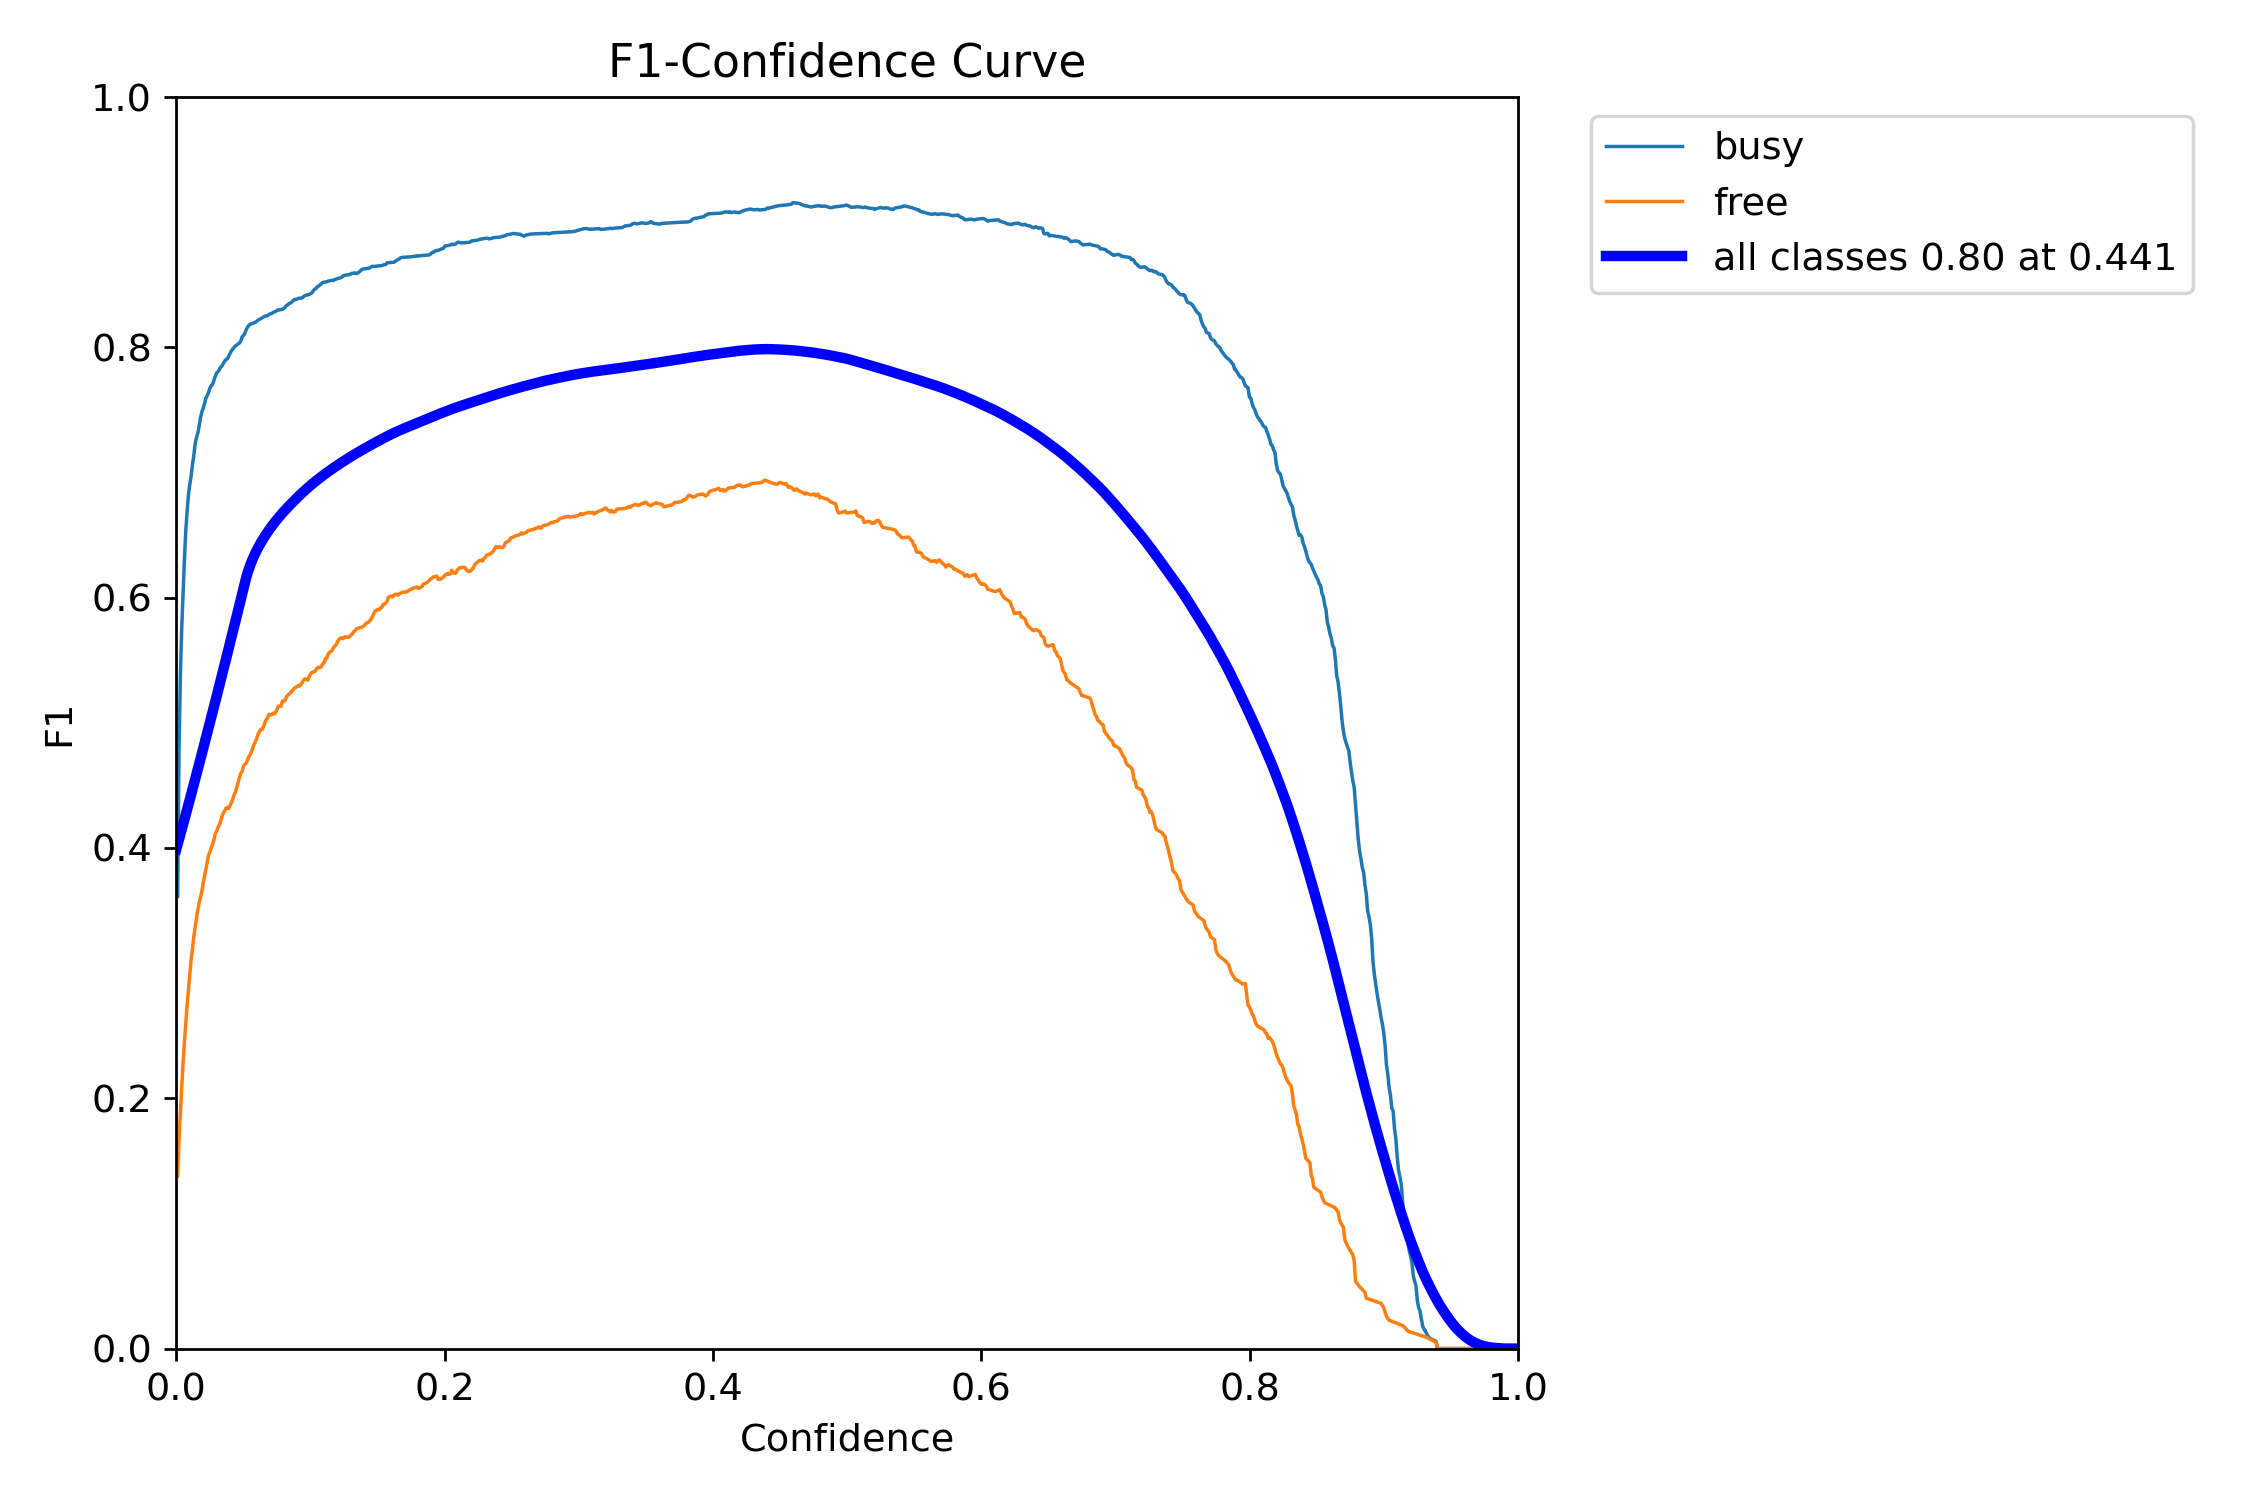

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import seaborn as sns
import numpy as np
from ultralytics import YOLO
from IPython.display import Image, display

# Carrega os modelos treinados com os melhores pesos
best_det = YOLO('runs/detect/custom_yolov8_detec/weights/best.pt')

# Executa a avaliação completa na base de TESTE
metrics = best_det.val(data=data_yaml_path, split='test', name='avaliacao_teste_detec', plots=True)

# -------------------------------------------------------------------
# Relatório das Métricas Formais
# -------------------------------------------------------------------
print("\n" + "="*50)
print("RELATÓRIO DE AVALIAÇÃO - BASE DE TESTE")
print("="*50)
print(f"Precisão Média (Precision):  {metrics.box.mp:.4f}")
print(f"Revocação Média (Recall):     {metrics.box.mr:.4f}")
print(f"mAP @ 0.50:                   {metrics.box.map50:.4f}")
print(f"mAP @ 0.50:0.95:              {metrics.box.map:.4f}")

# Média do IoU calculado entre predições válidas e o ground truth
if hasattr(metrics.box, 'mean_iou'):
    print(f"IoU Médio:                     {metrics.box.mean_iou:.4f}")

print("="*50)

# -------------------------------------------------------------------
# Exibe as Figuras Oficiais Geradas pelo YOLO no Teste
# -------------------------------------------------------------------
test_dir = metrics.save_dir

import glob

# Busca automaticamente os arquivos de imagem gerados no diretório de avaliação
graficos_encontrados = glob.glob(os.path.join(metrics.save_dir, '*.png'))

for caminho_img in graficos_encontrados:
    nome_arquivo = os.path.basename(caminho_img)
    print(f"\n--- Exibindo: {nome_arquivo} ---")
    display(Image(filename=caminho_img))


image 1/39 /content/Parking-places-3/test/images/130420_71_jpg.rf.5827843f68874665dc75ffee990eb05b.jpg: 640x640 26 busys, 2 frees, 7.2ms
image 2/39 /content/Parking-places-3/test/images/1661383309_10-idei-club-p-parkovka-vo-dvorakh-zhilikh-domov-oboi-15_jpg.rf.e14f928707750a9521ac65f8d7779829.jpg: 640x640 22 busys, 7 frees, 7.6ms
image 3/39 /content/Parking-places-3/test/images/2015-11-29_0844_jpg.rf.d89ed88f20d4d0157aa31d85835f3f31.jpg: 640x640 2 busys, 4 frees, 7.2ms
image 4/39 /content/Parking-places-3/test/images/2015-11-29_0944_jpg.rf.12f0b8fb7e5bad5e7ee733f293bf901d.jpg: 640x640 3 busys, 7 frees, 8.4ms
image 5/39 /content/Parking-places-3/test/images/2016-01-09_1028_jpg.rf.081b2807ec3c68d982ef57be156b17e7.jpg: 640x640 3 busys, 26 frees, 10.3ms
image 6/39 /content/Parking-places-3/test/images/2016-01-18_1710_jpg.rf.ffb22a04a97df74f3d7fce09454a92e9.jpg: 640x640 41 busys, 7 frees, 8.4ms
image 7/39 /content/Parking-places-3/test/images/5a07a1b1f7048519bd74c4a41c4721ea_jpeg.rf.528c05

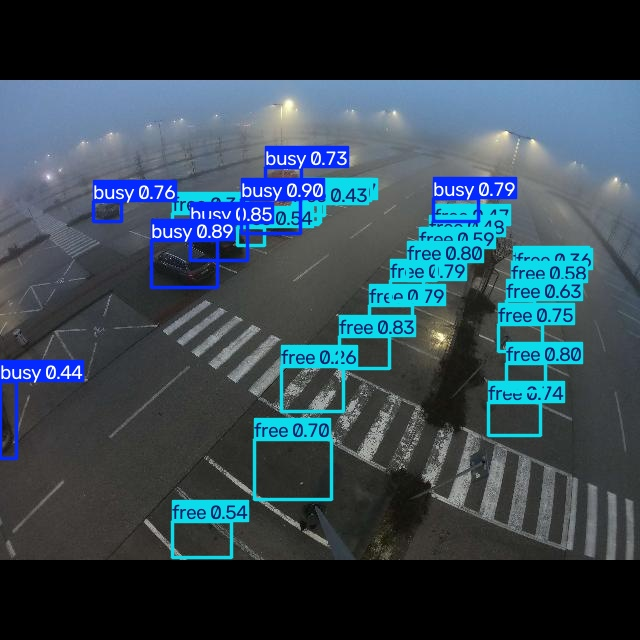


--- Imagem Predita: 5a07a1b1f7048519bd74c4a41c4721ea_jpeg.rf.528c05c3eea580fd1ac4527fedbef357.jpg ---


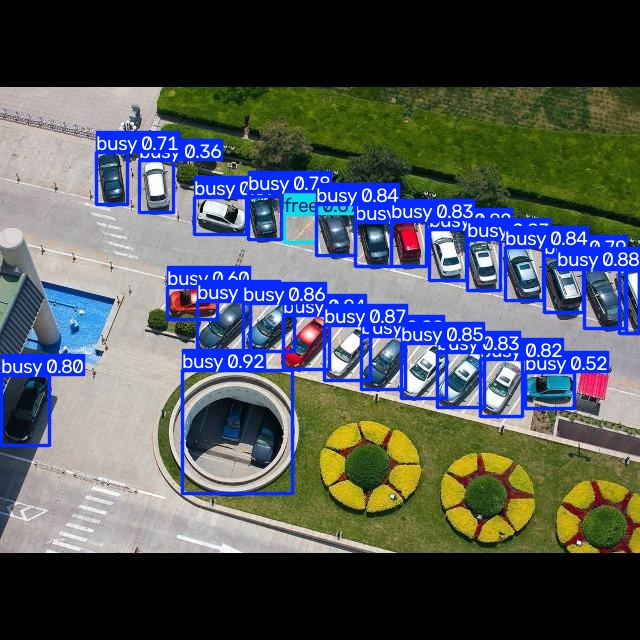


--- Imagem Predita: GOPR6613_JPG.rf.a34b0d5ad55c5633b6274a38a45abc06.jpg ---


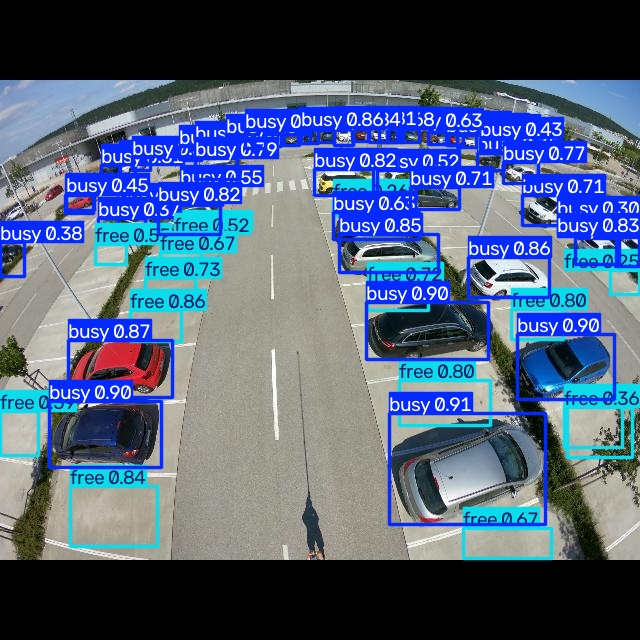

In [ ]:
#PAULOEDIT

import glob
from IPython.display import Image, display

# Executa a predição nas imagens do conjunto de teste
results_test = best_det.predict(
    source='/content/Parking-places-3/test/images',
    conf=0.25,
    save=True,
    name='predicoes_teste_exemplos'
)

# Lista e exibe as 3 primeiras imagens preditas para validação visual
imagens_preditas = glob.glob('/content/runs/detect/predicoes_teste_exemplos/*.jpg')

for caminho in imagens_preditas[:3]:
    print(f"\n--- Imagem Predita: {os.path.basename(caminho)} ---")
    display(Image(filename=caminho))

In [ ]:
#PAULOEDIT

# Avalia o modelo no conjunto de TESTE e extrai as métricas numéricas
metrics_det = best_det.val(
    data='/content/Parking-places-3/data.yaml',
    split='test'
)

# Exibe os resultados organizados
print("\n==========================================")
print("--- MÉTRICAS FASE 2 (YOLOv8n - DETECÇÃO) ---")
print("==========================================")
print(f"mAP@0.5:        {metrics_det.box.map50:.4f}")
print(f"mAP@0.5:0.95:   {metrics_det.box.map:.4f}")
print(f"Precisão:       {metrics_det.box.mp:.4f}")
print(f"Revogação:      {metrics_det.box.mr:.4f}")
print("==========================================\n")



Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1946.1±418.9 MB/s, size: 63.3 KB)
val: Scanning /content/Parking-places-3/test/labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 9.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.0s
                   all         39       1175      0.859       0.76      0.818      0.439
                  busy         39        740      0.904      0.918      0.961      0.626
                  free         39        435      0.814      0.603      0.675      0.253
Speed: 6.0ms preprocess, 5.3ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val-2

--- MÉTRICAS FASE 2 (YOLOv8n - DETECÇÃO) ---
mAP@0.5:        0.8184
mAP@0.5:0.95:   0.4391
Precis

### 4.1 Análise Qualitativa de Erros (exigida no relatório)

O `mAP` e o `recall` já mostram que o modelo erra desproporcionalmente mais na classe `free` (vaga livre) do que em `busy` (vaga ocupada). Aqui a gente vai atrás de exemplos concretos de falso positivo e falso negativo pra entender o porquê, comparando a predição do modelo treinado com o label original (ground truth) do dataset.

In [ ]:
# Analise qualitativa de erros: acha falso positivo e falso negativo comparando
# a predicao do modelo treinado com o ground truth (label original do dataset),
# usando IoU pra casar caixa prevista com caixa real. Foco na classe 'free',
# que e a que mais erra (recall 0.603 contra 0.918 da 'busy').

import numpy as np

def yolo_line_to_xyxy(line, img_w, img_h):
    cls_id, xc, yc, w, h = [float(v) for v in line.split()]
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    return int(cls_id), [x1, y1, x2, y2]

def iou_xyxy(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b
    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area_a = (xa2 - xa1) * (ya2 - ya1)
    area_b = (xb2 - xb1) * (yb2 - yb1)
    union = area_a + area_b - inter_area
    return inter_area / union if union > 0 else 0

test_img_dir = os.path.join(dataset_base_path, 'test', 'images')
test_lbl_dir = os.path.join(dataset_base_path, 'test', 'labels')
class_names_list = data_yaml_content and yaml.safe_load(data_yaml_content)['names']

erros_por_imagem = []
for img_path in glob.glob(os.path.join(test_img_dir, '*')):
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    lbl_path = os.path.join(test_lbl_dir, os.path.splitext(os.path.basename(img_path))[0] + '.txt')
    if not os.path.exists(lbl_path):
        continue
    gt_boxes = [yolo_line_to_xyxy(l, w, h) for l in open(lbl_path).read().splitlines() if l.strip()]

    pred = best_det.predict(img_path, conf=0.4, verbose=False)[0]
    pred_boxes = [(int(c), b.tolist()) for c, b in zip(pred.boxes.cls.tolist(), pred.boxes.xyxy)]

    matched_gt = set()
    falsos_positivos = 0
    for p_cls, p_box in pred_boxes:
        best_iou, best_j = 0, -1
        for j, (g_cls, g_box) in enumerate(gt_boxes):
            if g_cls == p_cls and j not in matched_gt:
                cur_iou = iou_xyxy(p_box, g_box)
                if cur_iou > best_iou:
                    best_iou, best_j = cur_iou, j
        if best_iou > 0.5:
            matched_gt.add(best_j)
        else:
            falsos_positivos += 1

    falsos_negativos_free = sum(
        1 for j, (g_cls, _) in enumerate(gt_boxes)
        if j not in matched_gt and class_names_list[g_cls] == 'free'
    )

    if falsos_negativos_free > 0 or falsos_positivos > 0:
        erros_por_imagem.append((img_path, falsos_negativos_free, falsos_positivos))

# Ordena pelas imagens com mais falso negativo de 'free' primeiro
erros_por_imagem.sort(key=lambda x: -x[1])

print(f"{len(erros_por_imagem)} imagens de teste com pelo menos um erro")
print("Top 3 com mais falso negativo de vaga livre (free):\n")

fig, axes = plt.subplots(1, min(3, len(erros_por_imagem)), figsize=(18, 6))
if len(erros_por_imagem) == 1:
    axes = [axes]
for ax, (img_path, fn_free, fp) in zip(axes, erros_por_imagem[:3]):
    pred = best_det.predict(img_path, conf=0.4, verbose=False)[0]
    ax.imshow(cv2.cvtColor(pred.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{os.path.basename(img_path)}\nFN 'free': {fn_free} | FP: {fp}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

_(comentário sobre os erros, escrito depois de olhar os exemplos da célula acima)_

O padrão mais claro é a diferença entre as duas classes: `busy` tem recall de 0,918 e mAP50 de 0,961, `free` tem recall de 0,603 e mAP50 de 0,675. Ou seja, o modelo deixa passar bem mais vaga livre do que vaga ocupada. Combinando isso com a EDA lá do começo do notebook, dá pra levantar duas hipóteses pra isso:

1. **Desbalanceamento de classe**: no split de teste (39 imagens) tem 740 instâncias de `busy` contra 435 de `free` (63%/37%). Não conferimos separadamente o split de treino, mas como o Roboflow gera os splits a partir do mesmo pool de imagens, é provável que a proporção se repita lá também
2. **Vaga livre é visualmente mais parecida com o fundo**: um carro estacionado (`busy`) tem contorno, cor e textura bem diferentes do asfalto; uma vaga vazia (`free`) é basicamente chão, faixa de demarcação e sombra, então é mais fácil confundir com o fundo ou com uma vaga parcialmente visível na borda da imagem

Nos exemplos com falso negativo de `free` acima, dá pra ver que boa parte é vaga na borda da imagem ou parcialmente sombreada, o que reforça a segunda hipótese. Pra melhorar isso, as saídas mais óbvias seriam: balancear as classes (oversampling de `free`, ou usar `class weights` no treino), aumentar as épocas focando em `free`, ou fazer mais data augmentation especificamente com variação de sombra/iluminação nessas imagens.

# **5. Segmentação de Instâncias (Fase 3)**

**Decisão do grupo:** o dataset "Parking places" só tem anotação de bounding box (`busy`/`free`), não tem máscara de segmentação nenhuma. Treinar um segmentador do zero exigiria anotar manualmente uma amostra, o que não dá tempo de fazer com qualidade até o prazo. Então, em vez de treinar/fine-tunar um modelo de segmentação no dataset das vagas, a gente **adaptou um modelo de segmentação já pré-treinado** (`yolov8n-seg.pt`, treinado no COCO) pra rodar em cima das mesmas imagens e do mesmo vídeo do estacionamento, filtrando só as classes de veículo (carro, ônibus, caminhão) e escondendo os rótulos genéricos do COCO pra ficar mais limpo visualmente.

Isso ainda conta como segmentação "no mesmo domínio" (o roadmap da sistematização permite treinar OU adaptar), só que sem fine-tuning específico nas classes `busy`/`free`. Por isso não tem métrica de mAP de máscara aqui, porque não existe anotação de máscara de referência pra comparar. A avaliação da segmentação, nesse caso, é só visual/qualitativa; isso precisa ficar registrado como limitação no relatório final.

In [ ]:
import os
from ultralytics import YOLO

# Mesma decisao de novo, agora aplicada no video: segmentacao adaptada
# (pre-treinada, restrita a veiculo), nao fine-tunada no dominio das vagas.

# CORRIGIDO: deu OutOfMemoryError na GPU rodando esse video (quase 1000 frames).
# Sem 'stream=True', o predict() guarda o resultado (com mascara) de TODOS os
# frames na memoria antes de terminar, e a GPU do Colab (T4, ~15GB) estoura.
# Com stream=True ele processa e libera frame a frame (generator), sem acumular.
# Por isso precisamos iterar o resultado (o 'for' abaixo), senao o generator nem roda.

# 1. Carregar o modelo de segmentação
model_seg_video = YOLO('yolov8n-seg.pt')

# 2. Processar o vídeo do estacionamento aplicando a segmentação de veículos
results_seg_vid = model_seg_video.predict(
    source='/content/parking_video.mp4',
    conf=0.10,
    classes=[2, 5, 7],
    show_labels=False,
    show_conf=False,
    save=True,
    stream=True,  # processa frame a frame, sem acumular tudo na memoria da GPU
    name='estacionamento_segmentacao_video'
)

# Precisa consumir o generator pra ele efetivamente processar e salvar o video
for _ in results_seg_vid:
    pass

print("\n==========================================")
print("Vídeo de Segmentação processado e salvo em:")
print("/content/runs/segment/estacionamento_segmentacao_video/parking_video.mp4")
print("==========================================\n")

# **6. Avaliação Final e Processamento de Vídeo (Fase 4)**

In [ ]:
import gdown

# Baixar o arquivo do vídeo de estacionamento de um link do google drive
video_url = 'https://drive.google.com/uc?id=1-LrtGphDIoRYiUsVPdck50Xq8ZF0Zthy'
output_path = '/content/parking_video.mp4'

gdown.download(video_url, output_path, quiet=False)

print(f"Vídeo baixado para: {output_path}")

Downloading...
From (original): https://drive.google.com/uc?id=1-LrtGphDIoRYiUsVPdck50Xq8ZF0Zthy
From (redirected): https://drive.google.com/uc?id=1-LrtGphDIoRYiUsVPdck50Xq8ZF0Zthy&confirm=t&uuid=9368e727-b731-4997-807f-5f5fc0a80897
To: /content/parking_video.mp4
100%|██████████| 269M/269M [00:04<00:00, 57.2MB/s]

Vídeo baixado para: /content/parking_video.mp4


# **7. Rastreamento de Objetos (ByteTrack)**

In [ ]:
from ultralytics import YOLO

# Carrega o modelo treinado
model_track = YOLO('/content/runs/detect/custom_yolov8_detec/weights/best.pt')

# Executa o rastreamento com ByteTrack
results_track = model_track.track(
    source='/content/parking_video.mp4',
    tracker='bytetrack.yaml',
    conf=0.25,
    save=True,
    name='estacionamento_bytetrack'
)

print("\n==========================================")
print("Rastreamento concluído e salvo em:")
print("/content/runs/detect/estacionamento_bytetrack/parking_video.mp4")
print("==========================================\n")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/959) /content/parking_video.mp4: 384x640 13 busys, 6.6ms
video 1/1 (frame 2/959) /content/parking_video.mp4: 384x640 10 busys, 9.4ms
video 1/1 (frame 3/959) /content/parking_video.mp4: 384x640 10 busys, 9.2ms
video 1/1 (frame 4/959) /content/parking_video.mp4: 384x640 12 busys, 9.2ms
video 1/1 (frame 5/959) /content/parking_video.mp4: 384x640 10 busys, 9.1ms
video 1/1 (frame 6/959) /content/parking_video.mp4: 384x640 12 busys, 9.0ms
vid

In [ ]:
from ultralytics import YOLO

# Carrega o modelo treinado
model_track = YOLO('/content/runs/detect/custom_yolov8_detec/weights/best.pt')

# CORRIGIDO preventivamente: a celula de segmentacao no video deu OutOfMemoryError
# nesse mesmo video (quase 1000 frames) por nao usar stream=True. Aplicando a
# mesma correcao aqui antes de rodar, pra nao travar de novo no rastreamento.
results_track = model_track.track(
    source='/content/parking_video.mp4',
    tracker='bytetrack.yaml',
    conf=0.25,
    save=True,
    stream=True,  # processa frame a frame, sem acumular tudo na memoria da GPU
    name='estacionamento_bytetrack'
)

# Precisa consumir o generator pra ele efetivamente processar e salvar o video
for _ in results_track:
    pass

print("\n==========================================")
print("Rastreamento concluído e salvo em:")
print("/content/runs/detect/estacionamento_bytetrack/parking_video.mp4")
print("==========================================\n")

In [ ]:
import os
import cv2
from IPython.display import HTML
from base64 import b64encode
from ultralytics import YOLO

# 1. Carrega o modelo -- CORRIGIDO: antes estava 'yolov8n.pt' (generico, sem treino).
#    Agora usa o modelo treinado na Fase 2, pra detectar busy/free de verdade.
model = YOLO('runs/detect/custom_yolov8_detec/weights/best.pt')

video_input = '/content/parking_video.mp4'
video_temp = '/content/video_temp.mp4'
video_output = '/content/video_anotado_h264.mp4'

# -------------------------------------------------------------------
# PASSO 1: Processa o vídeo e salva no disco
# -------------------------------------------------------------------
cap = cv2.VideoCapture(video_input)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

# Criamos um arquivo temporário de saída
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_temp, fourcc, fps, (width, height))

print("Processando o vídeo e desenhando as detecções...")
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, conf=0.5, verbose=False)
    annotated_frame = results[0].plot()
    out.write(annotated_frame)

cap.release()
out.release()
print("Processamento concluído!")

# -------------------------------------------------------------------
# PASSO 2: Converte o vídeo para o formato H.264 (compatível com navegador)
# -------------------------------------------------------------------
print("Convertendo formato para compatibilidade com o navegador...")
os.system(f"ffmpeg -y -i {video_temp} -vcodec libx264 {video_output} -loglevel quiet")

# -------------------------------------------------------------------
# PASSO 3: Exibe o player de vídeo HTML5 no Colab
# -------------------------------------------------------------------
def show_video_in_colab(video_path, width=640):
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f'''
    <video width="{width}" controls autoplay loop>
          <source src="{data_url}" type="video/mp4">
          Seu navegador não suporta a tag de vídeo HTML5.
    </video>
    ''')

# Renderiza o player nativo
show_video_in_colab(video_output)